In [119]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.linalg as LA

import Hamiltonian as Hamiltonian
import Plotting as plotting
import constants as cst

### Exploring the Hamiltonian: Generating 3 sets of band structures

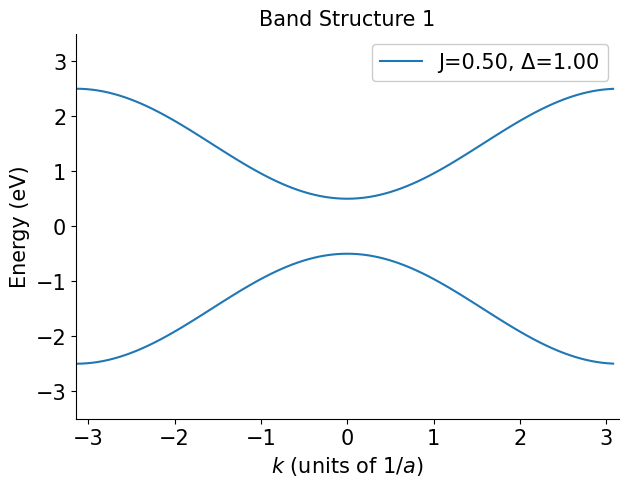

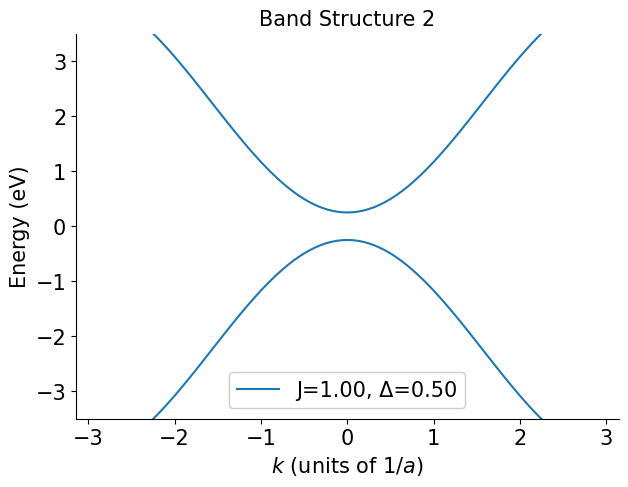

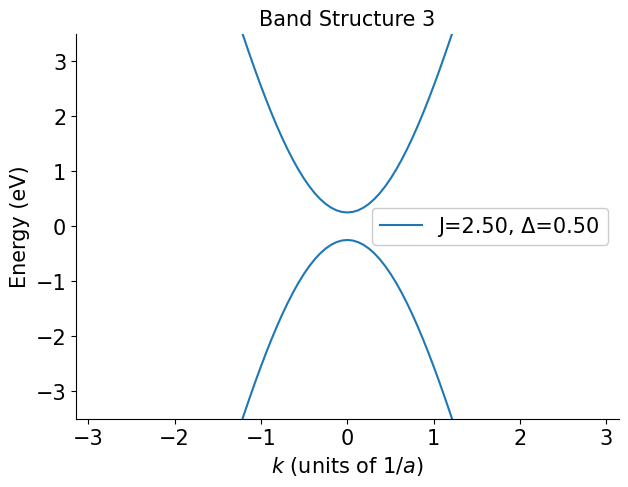

0

In [120]:
k_vals = np.linspace(-np.pi, np.pi, 101)[:-1]

#---------- First plot : -------------------

J_list     = np.array([0.5])/cst.Ry
delta_list = np.array([1.0])/cst.Ry


valence_bands    = {}
conduction_bands = {}
for J in J_list:
    for Δ in delta_list:
        valence_bands[J,Δ]    = Hamiltonian.eps_vb( k_vals, J, Δ )
        conduction_bands[J,Δ] = Hamiltonian.eps_cb( k_vals, J, Δ )

limits=np.array([[-np.pi,np.pi],[-3.5,3.5]])

plotting.plot_band_structure(
    Title="Band Structure 1", k_vals=k_vals, J_list=J_list, delta_list=delta_list, vb=valence_bands, cb=conduction_bands, limits=limits, fout='')


#---------- Second plot : -------------------

J_list     = np.array([1.0])/cst.Ry
delta_list = np.array([0.5])/cst.Ry


valence_bands    = {}
conduction_bands = {}
for J in J_list:
    for Δ in delta_list:
        valence_bands[J,Δ]    = Hamiltonian.eps_vb( k_vals, J, Δ )
        conduction_bands[J,Δ] = Hamiltonian.eps_cb( k_vals, J, Δ )

limits=np.array([[-np.pi,np.pi],[-3.5,3.5]])

plotting.plot_band_structure("Band Structure 2", k_vals, J_list, delta_list, valence_bands, conduction_bands, limits,fout='')



#---------- Third plot : -------------------

J_list     = np.array([2.5])/cst.Ry
delta_list = np.array([0.5])/cst.Ry


valence_bands    = {}
conduction_bands = {}
for J in J_list:
    for Δ in delta_list:
        valence_bands[J,Δ]    = Hamiltonian.eps_vb( k_vals, J, Δ )
        conduction_bands[J,Δ] = Hamiltonian.eps_cb( k_vals, J, Δ )

limits=np.array([[-np.pi,np.pi],[-3.5,3.5]])

plotting.plot_band_structure("Band Structure 3", k_vals, J_list, delta_list, valence_bands, conduction_bands, limits,fout='')



### Exploring the E Field: Generating 3 different fields

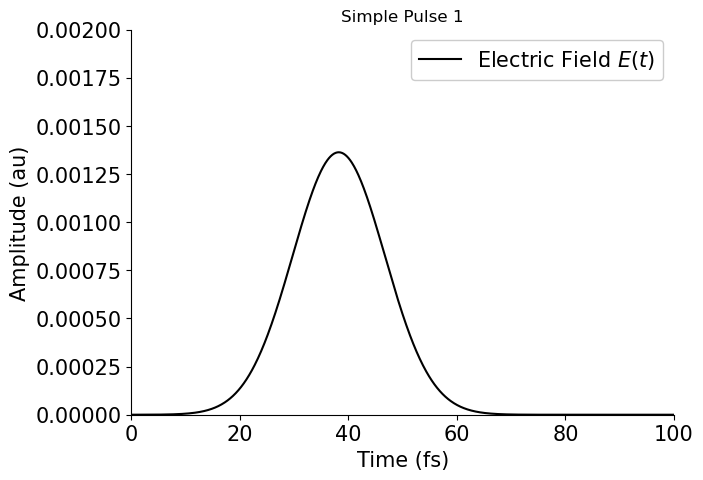

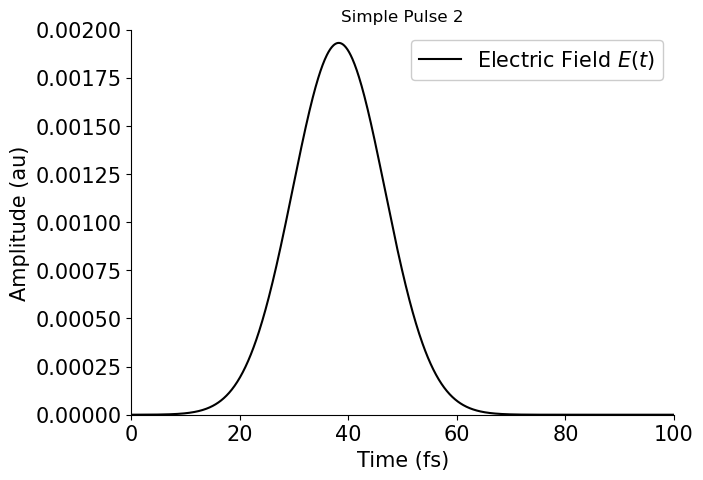

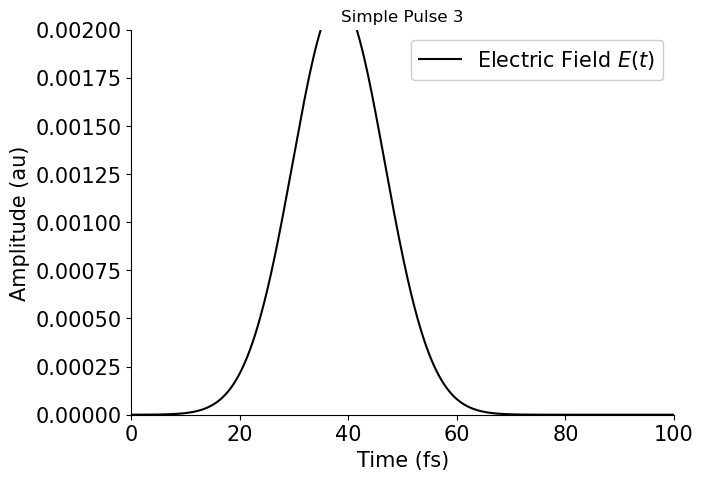

0

In [121]:
case=1

t = np.linspace(0, 100, 1000)/ cst.tfs

#-------------- Simple Pulse 1 --------------

FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 1.2

efield_case1 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
plotting.plot_electric_pulse("Simple Pulse 1",t*cst.tfs, efield_case1, np.array([[0,100],[-0.002*0,0.002]]),fout='')




#-------------- Simple Pulse 2 --------------

FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 1.7

efield_case1 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
plotting.plot_electric_pulse("Simple Pulse 2", t*cst.tfs, efield_case1, np.array([[0,100],[-0.002*0,0.002]]),fout='')



#-------------- Simple Pulse 3 --------------

FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 1.9

efield_case1 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
plotting.plot_electric_pulse("Simple Pulse 3", t*cst.tfs, efield_case1, np.array([[0,100],[-0.002*0,0.002]]),fout='')



### Exploring the 9 possible combinations of the above 

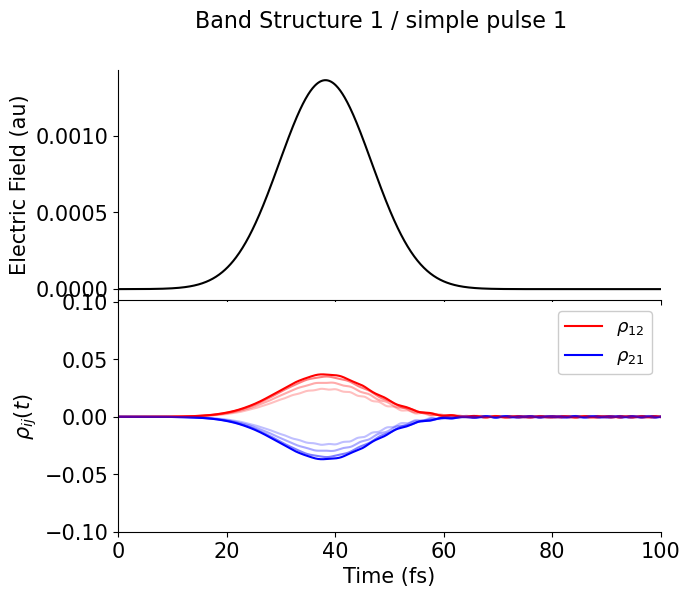

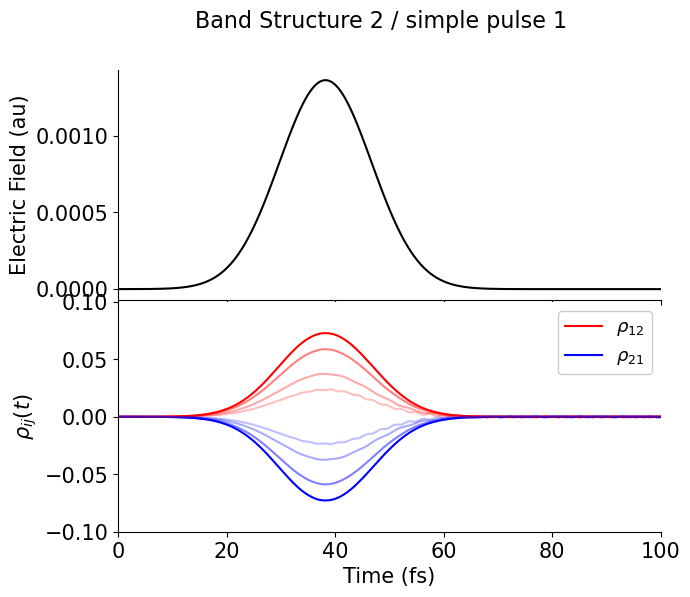

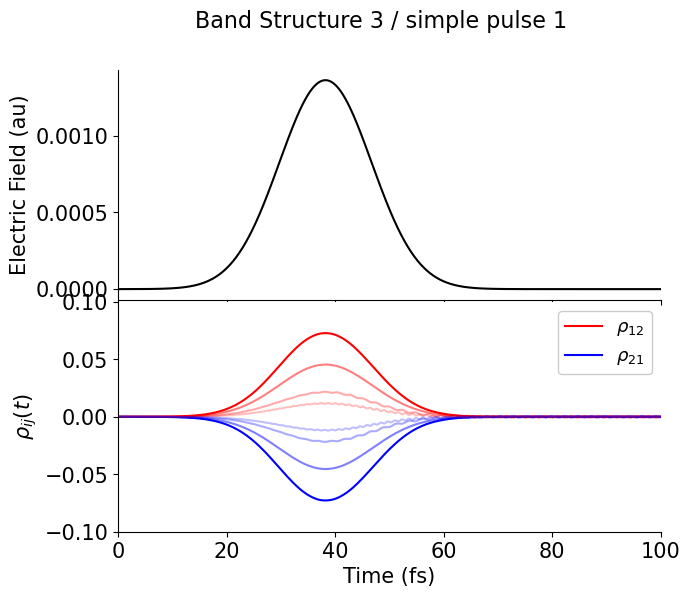

0

In [122]:
#-------------- Simple Pulse 1 --------------
#case = 1
FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 1.2

efield_case1 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
#plotting.plot_electric_pulse("Simple Pulse 1",t*cst.tfs, efield_case1, np.array([[0,100],[-0.002*0,0.002]]),fout='')




#------------ Band Structure 1 / simple pulse 1 --------------

J     = 0.5/cst.Ry
delta = 1/cst.Ry
k_list=[0, 0.25, 0.50, 0.75]

t_span= (t[0],t[-1])

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]

limits=np.array([[0,100],[-0.1,0.1]])
plotting.plot_OD_population_field("Band Structure 1 / simple pulse 1", t*cst.tfs,efield_case1,k_list,solutions.real,limits)





#------------ Band Structure 2 / simple pulse 1 --------------

J     = 1/cst.Ry
delta = 0.5/cst.Ry
k_list=[0, 0.25, 0.50, 0.75]

t_span= (t[0],t[-1])

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]

limits=np.array([[0,100],[-0.1,0.1]])
plotting.plot_OD_population_field("Band Structure 2 / simple pulse 1", t*cst.tfs,efield_case1,k_list,solutions.real ,limits)



#------------ Band Structure 3 / simple pulse 1 --------------

J     = 2.5/cst.Ry
delta = 0.5/cst.Ry
k_list=[0, 0.25, 0.50, 0.75]

t_span= (t[0],t[-1])

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]

    
limits=np.array([[0,100],[-0.1,0.1]])
plotting.plot_OD_population_field("Band Structure 3 / simple pulse 1", t*cst.tfs,efield_case1,k_list,solutions.real,limits)









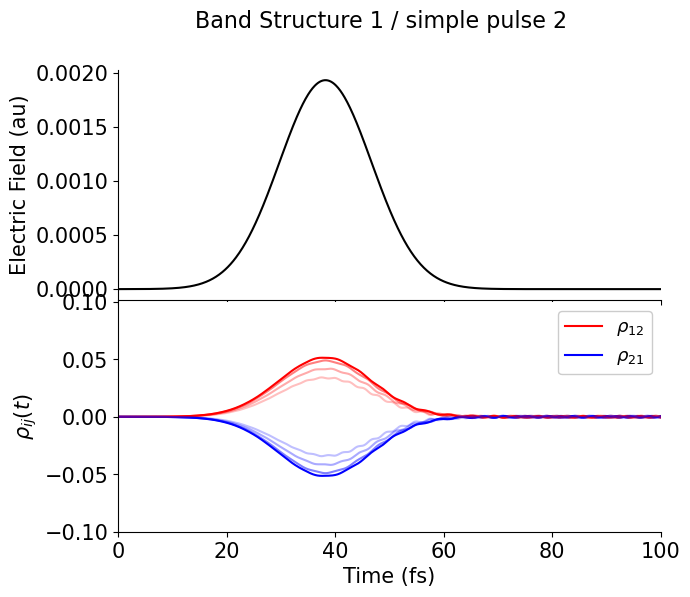

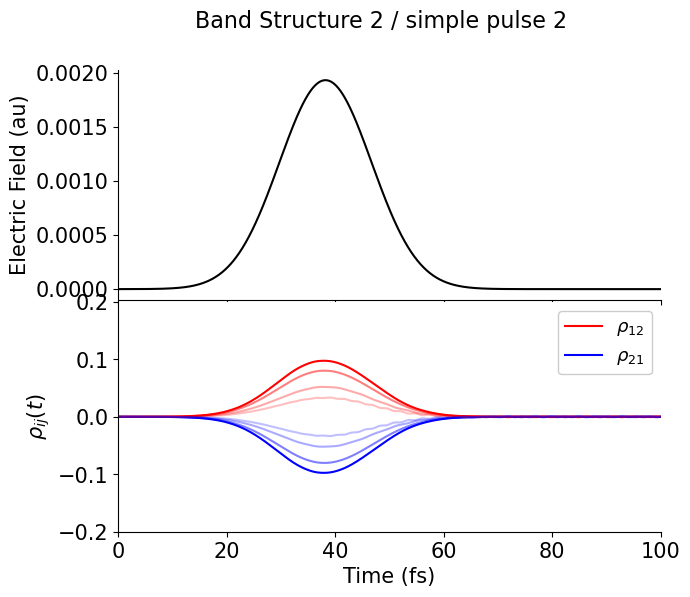

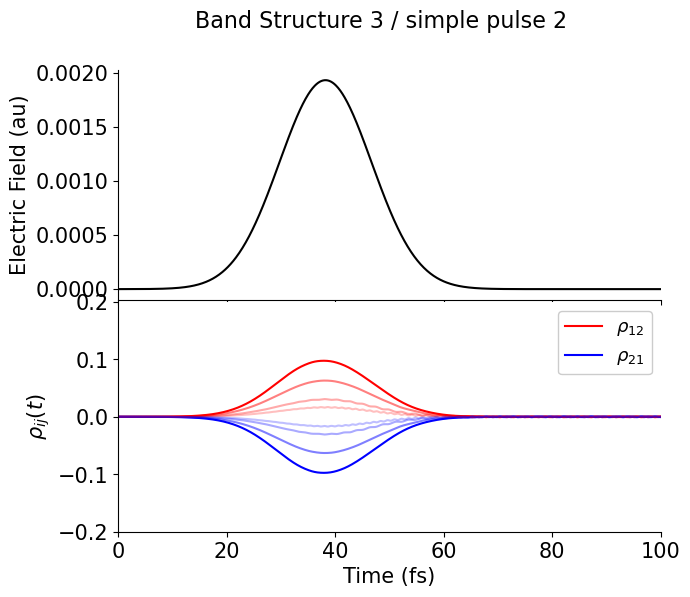

0

In [123]:


#-------------- Simple Pulse 2 --------------

FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 1.7

efield_case1 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
#plotting.plot_electric_pulse("Simple Pulse 2", t*cst.tfs, efield_case1, np.array([[0,100],[-0.002*0,0.002]]),fout='')



#------------ Band Structure 1 / simple pulse 2 --------------

J     = 0.5/cst.Ry
delta = 1/cst.Ry
k_list=[0, 0.25, 0.50, 0.75]

t_span= (t[0],t[-1])

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]

    
limits=np.array([[0,100],[-0.1,0.1]])
plotting.plot_OD_population_field("Band Structure 1 / simple pulse 2", t*cst.tfs,efield_case1,k_list,solutions.real,limits)





#------------ Band Structure 2 / simple pulse 2 --------------

J     = 1/cst.Ry
delta = 0.5/cst.Ry
k_list=[0, 0.25, 0.50, 0.75]

t_span= (t[0],t[-1])

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
    
limits=np.array([[0,100],[-0.2,0.2]])
plotting.plot_OD_population_field("Band Structure 2 / simple pulse 2", t*cst.tfs,efield_case1,k_list,solutions.real,limits)



#------------ Band Structure 3 / simple pulse 2 --------------

J     = 2.5/cst.Ry
delta = 0.5/cst.Ry
k_list=[0, 0.25, 0.50, 0.75]

t_span= (t[0],t[-1])

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]

    
limits=np.array([[0,100],[-0.2,0.2]])
plotting.plot_OD_population_field("Band Structure 3 / simple pulse 2", t*cst.tfs,efield_case1,k_list,solutions.real,limits)

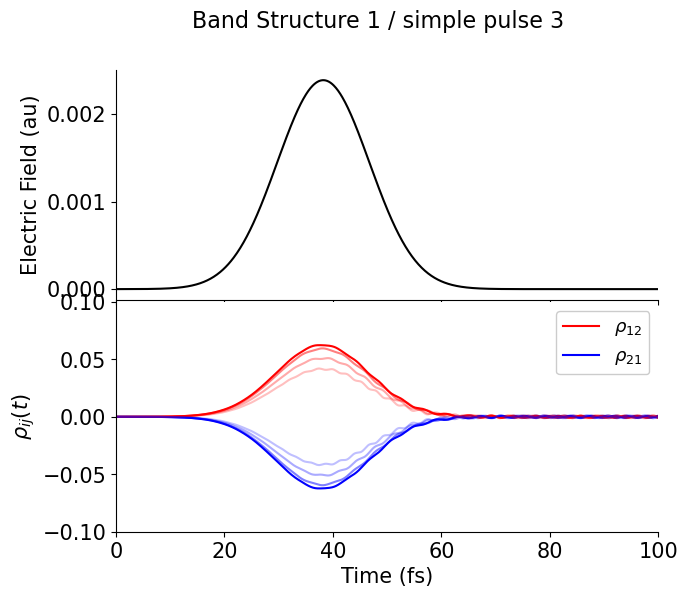

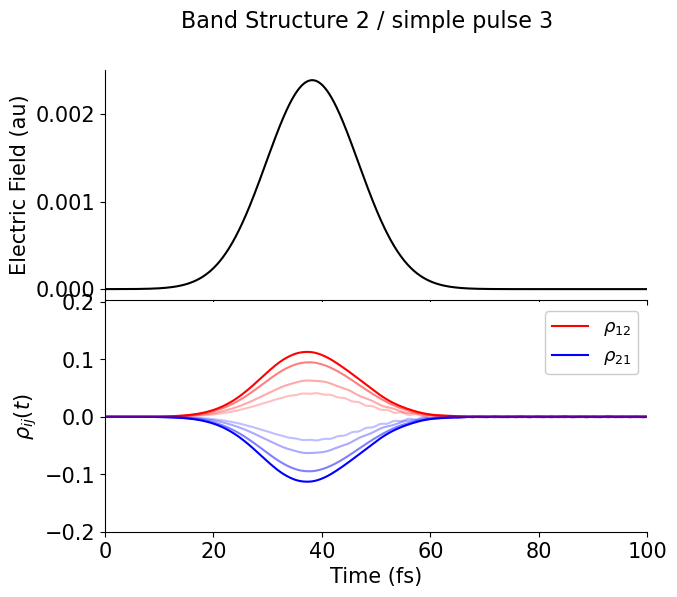

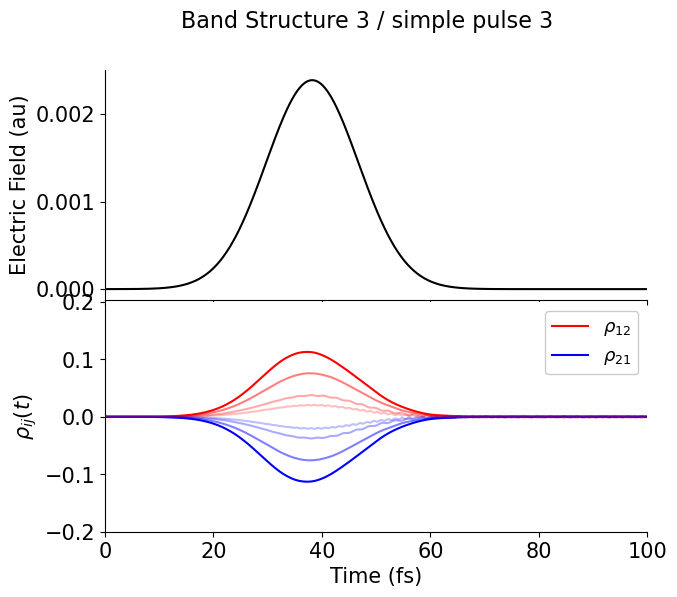

0

In [124]:

#-------------- Simple Pulse 3 --------------

FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 2.1

efield_case1 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
#plotting.plot_electric_pulse("Simple Pulse 3", t*cst.tfs, efield_case1, np.array([[0,100],[-0.002*0,0.002]]),fout='')



#------------ Band Structure 1 / simple pulse 3 --------------

J     = 0.5/cst.Ry
delta = 1/cst.Ry
k_list=[0, 0.25, 0.50, 0.75]

t_span= (t[0],t[-1])

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
    
limits=np.array([[0,100],[-0.1,0.1]])
plotting.plot_OD_population_field("Band Structure 1 / simple pulse 3", t*cst.tfs,efield_case1,k_list,solutions.real,limits)





#------------ Band Structure 2 / simple pulse 3 --------------

J     = 1/cst.Ry
delta = 0.5/cst.Ry
k_list=[0, 0.25, 0.50, 0.75]

t_span= (t[0],t[-1])

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
    
limits=np.array([[0,100],[-0.2,0.2]])
plotting.plot_OD_population_field("Band Structure 2 / simple pulse 3", t*cst.tfs,efield_case1,k_list,solutions.real,limits)



#------------ Band Structure 3 / simple pulse 3 --------------

J     = 2.5/cst.Ry
delta = 0.5/cst.Ry
k_list=[0, 0.25, 0.50, 0.75]

t_span= (t[0],t[-1])

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]

    
limits=np.array([[0,100],[-0.2,0.2]])
plotting.plot_OD_population_field("Band Structure 3 / simple pulse 3", t*cst.tfs,efield_case1,k_list,solutions.real,limits)


### Exploring the envelope E field: 3 cases

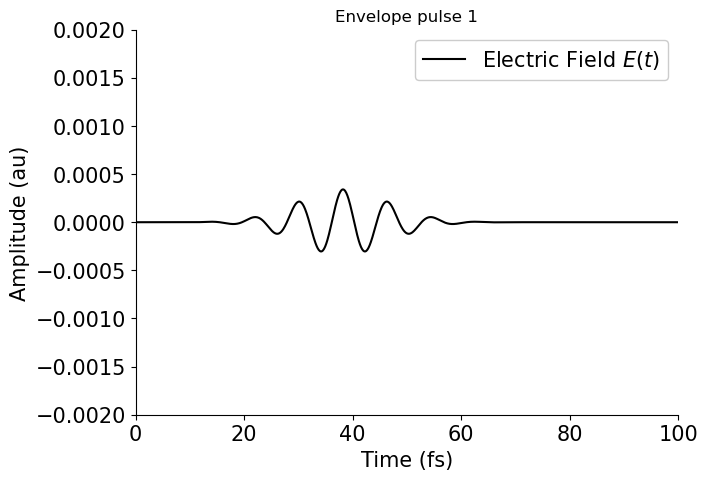

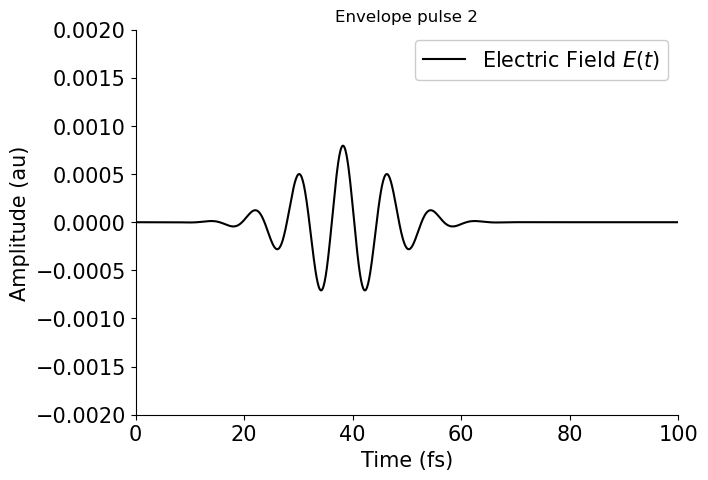

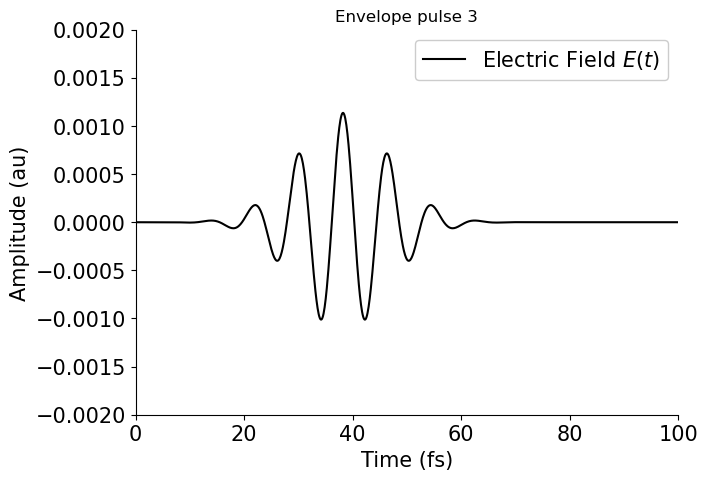

0

In [125]:
case=2

t = np.linspace(0, 100, 1000)/ cst.tfs


#---------------- Envelope pulse 1 ---------------

FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 0.3

efield_case2 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
plotting.plot_electric_pulse("Envelope pulse 1", t*cst.tfs, efield_case2, np.array([[0,100],[-0.002,0.002]]),fout='')


#---------------- Envelope pulse 2 ---------------

FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 0.7

efield_case2 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
plotting.plot_electric_pulse("Envelope pulse 2", t*cst.tfs, efield_case2, np.array([[0,100],[-0.002,0.002]]),fout='')


#---------------- Envelope pulse 3 ---------------

FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 1.0

efield_case2 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
plotting.plot_electric_pulse("Envelope pulse 3", t*cst.tfs, efield_case2, np.array([[0,100],[-0.002,0.002]]),fout='')







### Exploring the 9 possible combinations of the above 

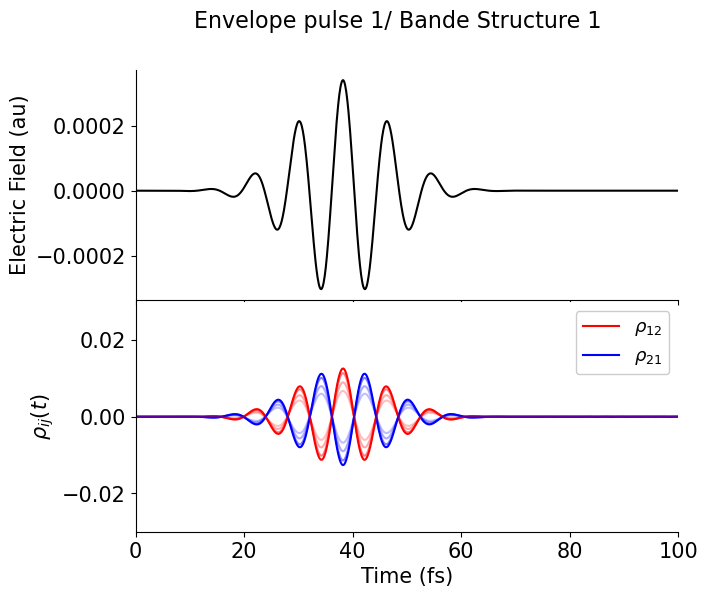

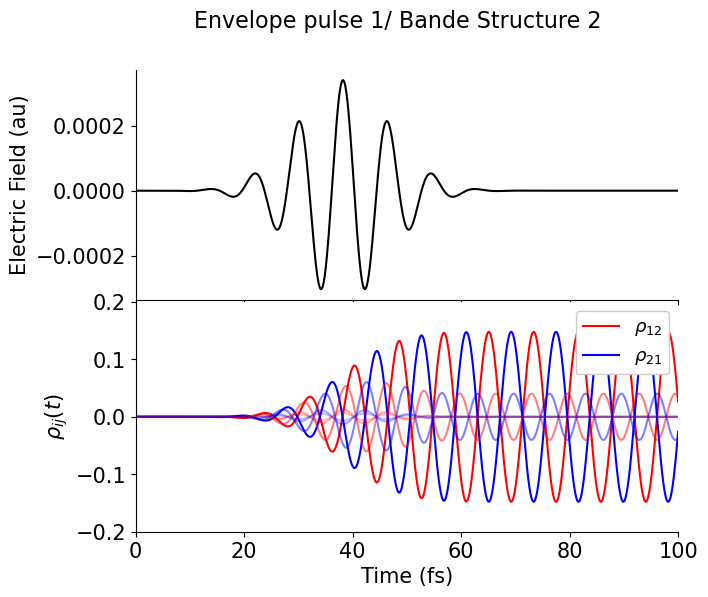

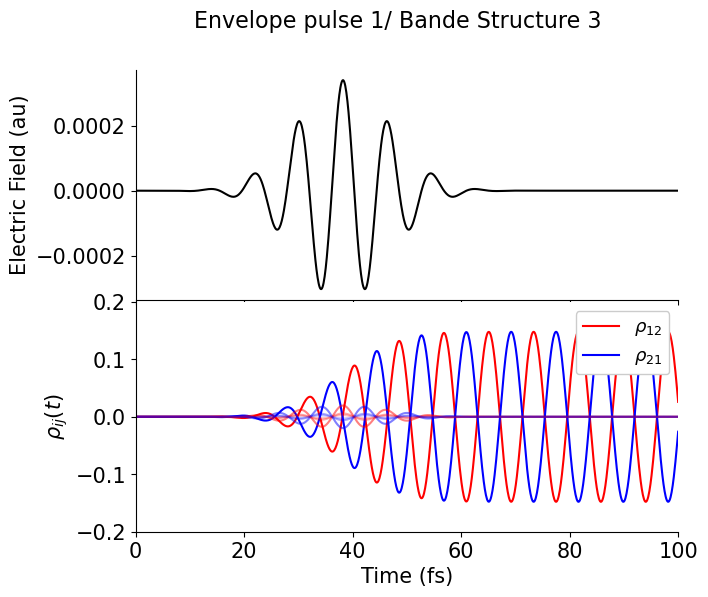

0

In [126]:

#---------------- Envelope pulse 1 ---------------

FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 0.3

efield_case2 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
#plotting.plot_electric_pulse("Envelope pulse 1", t*cst.tfs, efield_case2, np.array([[0,100],[-0.002,0.002]]),fout='')

k_list=[0, 0.25, 0.50, 0.75]
t_span= (t[0],t[-1])

#---------------- Envelope pulse 1/ Bande Structure 1---------------
J     = 0.5/cst.Ry
delta = 1.0/cst.Ry

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]

    
limits=np.array([[0,100],[-0.030,0.030]])
plotting.plot_OD_population_field("Envelope pulse 1/ Bande Structure 1", t*cst.tfs,efield_case2,k_list,solutions.real,limits)


#---------------- Envelope pulse 1/ Bande Structure 2---------------
J     = 1.0/cst.Ry
delta = 0.5/cst.Ry

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
    
limits=np.array([[0,100],[-0.20,0.20]])
plotting.plot_OD_population_field("Envelope pulse 1/ Bande Structure 2", t*cst.tfs,efield_case2,k_list,solutions.real,limits)



#---------------- Envelope pulse 1/ Bande Structure 3---------------
J     = 2.5/cst.Ry
delta = 0.5/cst.Ry

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
    
limits=np.array([[0,100],[-0.20,0.20]])
plotting.plot_OD_population_field("Envelope pulse 1/ Bande Structure 3", t*cst.tfs,efield_case2,k_list,solutions.real,limits)


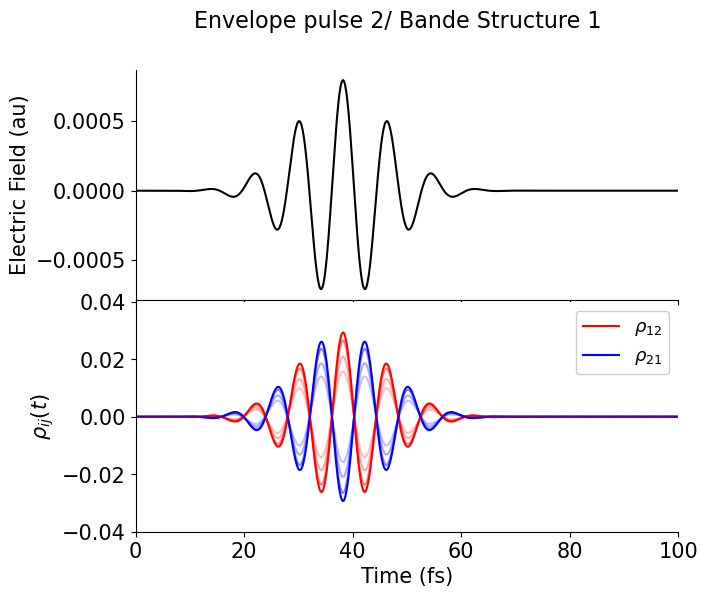

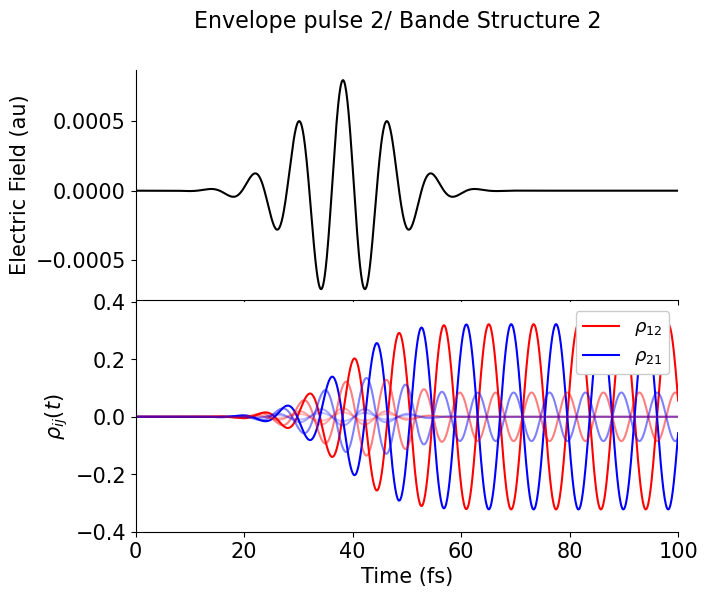

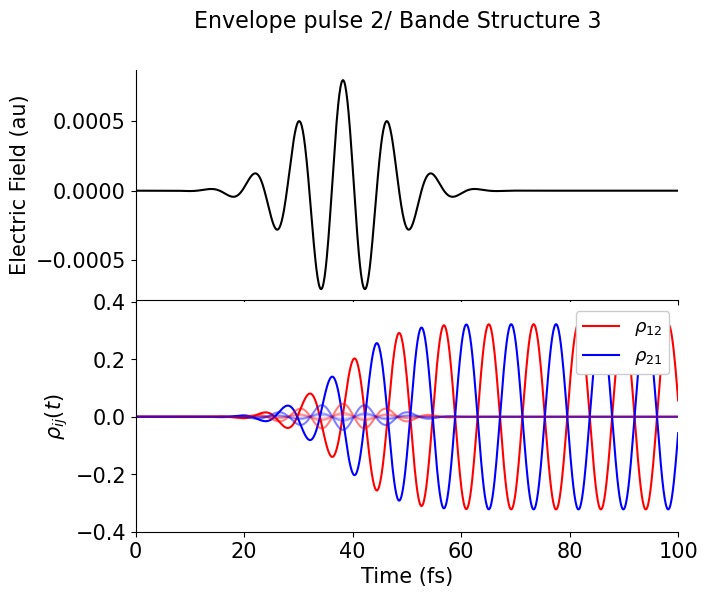

0

In [127]:

#---------------- Envelope pulse 2 ---------------

FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 0.7

efield_case2 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
#plotting.plot_electric_pulse("Envelope pulse 2", t*cst.tfs, efield_case2, np.array([[0,100],[-0.002,0.002]]),fout='')



#---------------- Envelope pulse 1/ Bande Structure 1---------------
J     = 0.5/cst.Ry
delta = 1.0/cst.Ry

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]

    
limits=np.array([[0,100],[-0.040,0.040]])
plotting.plot_OD_population_field("Envelope pulse 2/ Bande Structure 1", t*cst.tfs,efield_case2,k_list,solutions.real,limits)


#---------------- Envelope pulse 2/ Bande Structure 2---------------
J     = 1.0/cst.Ry
delta = 0.5/cst.Ry

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
    
limits=np.array([[0,100],[-0.40,0.40]])
plotting.plot_OD_population_field("Envelope pulse 2/ Bande Structure 2", t*cst.tfs,efield_case2,k_list,solutions.real,limits)



#---------------- Envelope pulse 2/ Bande Structure 3---------------
J     = 2.5/cst.Ry
delta = 0.5/cst.Ry

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]

    
limits=np.array([[0,100],[-0.40,0.40]])
plotting.plot_OD_population_field("Envelope pulse 2/ Bande Structure 3", t*cst.tfs,efield_case2,k_list,solutions.real,limits)




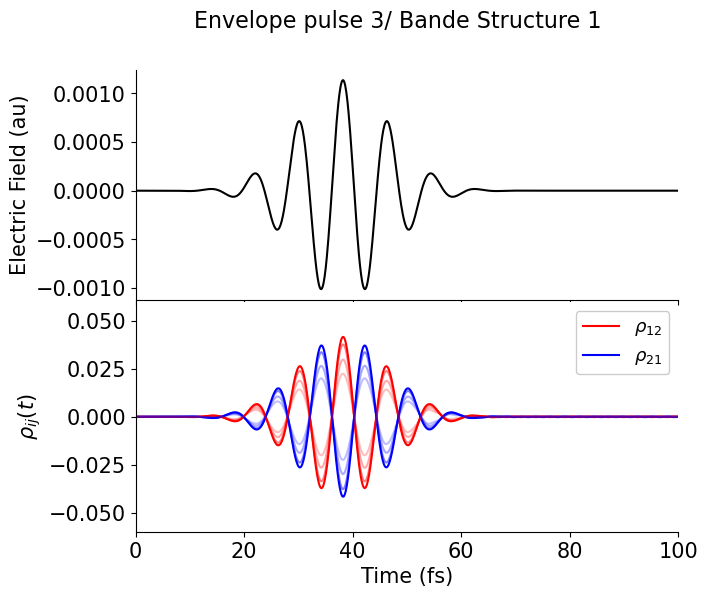

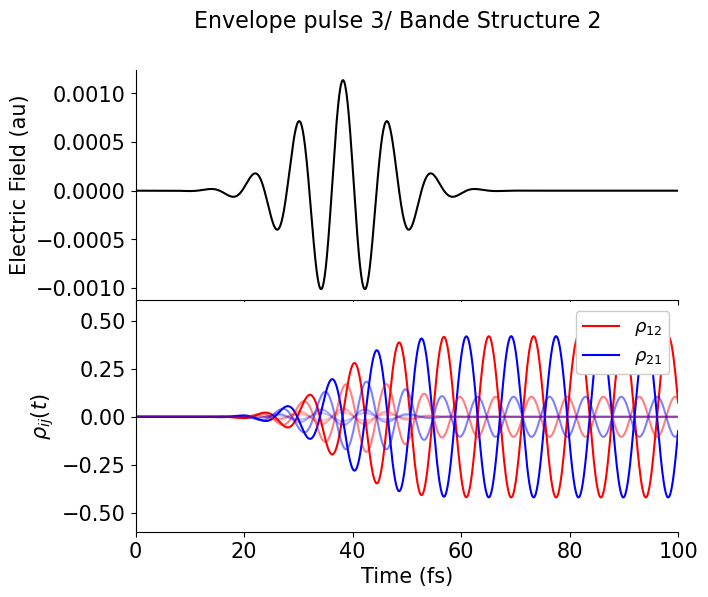

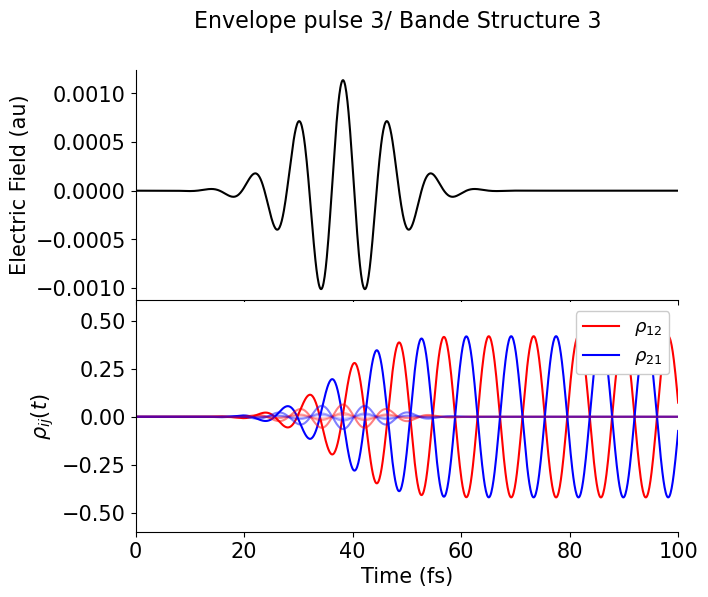

0

In [128]:

#---------------- Envelope pulse 3 ---------------

FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 1.0

efield_case2 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
#plotting.plot_electric_pulse("Envelope pulse 3", t*cst.tfs, efield_case2, np.array([[0,100],[-0.002,0.002]]),fout='')

#---------------- Envelope pulse 3/ Bande Structure 1---------------
J     = 0.5/cst.Ry
delta = 1.0/cst.Ry

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]

    
limits=np.array([[0,100],[-0.06,0.06]])
plotting.plot_OD_population_field("Envelope pulse 3/ Bande Structure 1", t*cst.tfs,efield_case2,k_list,solutions.real,limits)


#---------------- Envelope pulse 3/ Bande Structure 2---------------
J     = 1.0/cst.Ry
delta = 0.5/cst.Ry

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]

    
limits=np.array([[0,100],[-0.6,0.60]])
plotting.plot_OD_population_field("Envelope pulse 3/ Bande Structure 2", t*cst.tfs,efield_case2,k_list,solutions.real,limits)


#---------------- Envelope pulse 3/ Bande Structure 3---------------
J     = 2.5/cst.Ry
delta = 0.5/cst.Ry

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]

    
limits=np.array([[0,100],[-0.60,0.60]])
plotting.plot_OD_population_field("Envelope pulse 3/ Bande Structure 3", t*cst.tfs,efield_case2,k_list,solutions.real,limits)






# Using DMD Package

The code below uses a significant time delay (and hankel preprocessing) in order to generate a proper DMD. It works very well for k=50 (maximum amplitude). 

It does't work as well for smaller amplitudes (Large relative error, but very small absolute error considering the size of the amplitudes )

### A first case 

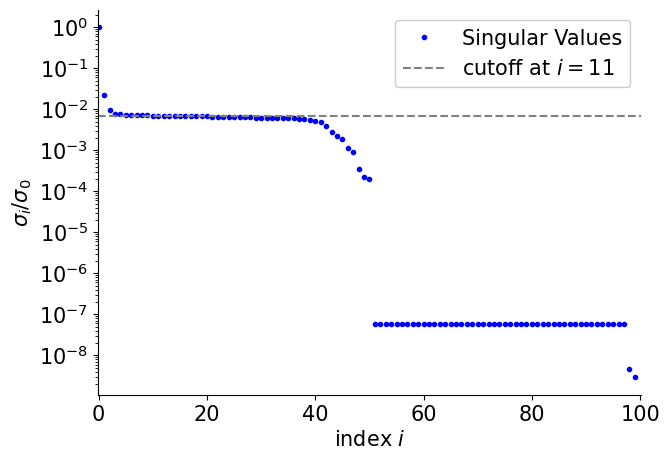

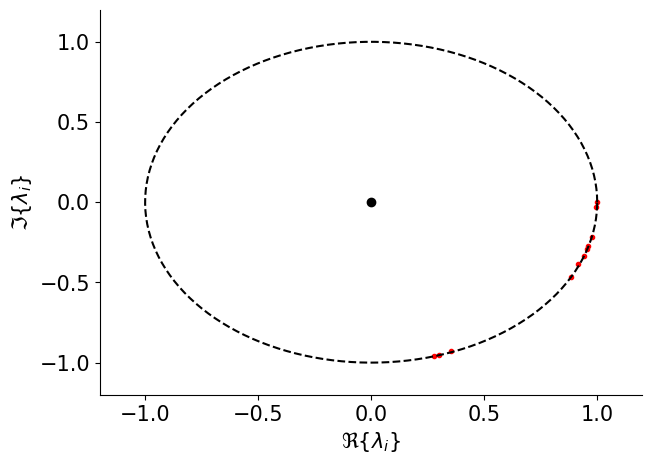

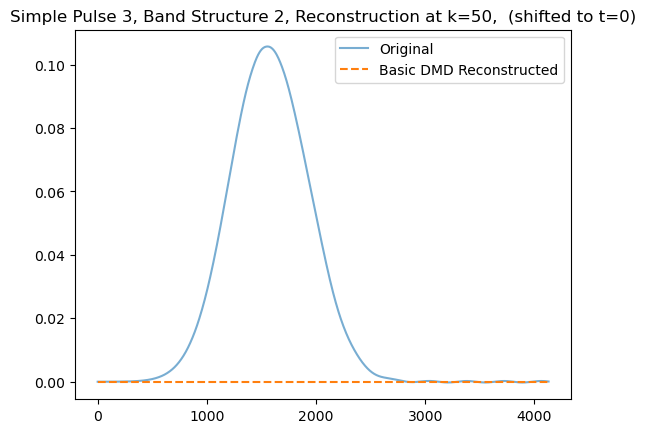

In [ ]:


from pydmd import DMD
from pydmd.plotter import plot_eigs, plot_summary
from pydmd.preprocessing import hankel_preprocessing


# ====== Set up the simulation ======
#-------------- Simple Pulse 3 / Band structure 2--------------

case = 1
FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 1.9
efield_case1 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
t = np.linspace(0, 100, 1000)/ cst.tfs
J      = 1.0/cst.Ry
delta  = 0.5/cst.Ry
k_list = np.linspace(-np.pi, np.pi, 101)[:-1]

t_span= (t[0],t[-1])




solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
limits=np.array([[0,100],[0.0,0.2]])



#Get the simualtion ready for DMD use:
t_dmd = t[:-1]  # because X and Y have 999 time steps
X = solutions[:, 0, :-1]  # shape: (num_k, len(t)-1)
Y = solutions[:, 0, 1:]   # one step ahead




# ========= Apply DMD ===========
rank=11
index=50
#truncamiento=-6


eigvals, Phi_L, r_L, S      = Hamiltonian.perform_dmd(X, Y, t, rank)
mu, Phi_M, r_M, Sig2 = Hamiltonian.DMD(X, Y, False, orden_truncado=rank)
plotting.plot_singular_values(Sig2,rank, False) 
plotting.plot_eigenvalues(mu)


delay = 1  # we will use this number of delays throughout the tutorial    (600)      #reset to 400 
dmd = DMD(svd_rank=rank)
delay_dmd = hankel_preprocessing(dmd, d=delay)
delay_dmd.fit(X)

# Reconstruction
X_dmd = dmd.reconstructed_data.real  # or .imag or .abs()
# Optional: get eigenvalues or modes
eigs = dmd.eigs
modes = dmd.modes


# Chop the first 399 time points to align with DMD output
t_dmd_shifted = t_dmd[:1000-delay] #1000-delay
#t_dmd_shifted = t_dmd[delay-1:] #use this line instead of the line above and DMD will stop working (also reset delay=2)

# Truncate DMD data to match the shortened time axis
x_dmd_shifted = X_dmd[index].real[:len(t_dmd_shifted)] 


# Plot
plt.plot(t_dmd, X[index].real, label="Original", alpha=0.6)
plt.plot(t_dmd_shifted, x_dmd_shifted, label="Basic DMD Reconstructed", linestyle='--') #delayed_DMD Reconstructed
plt.legend()
plt.title(f"Simple Pulse 3, Band Structure 2, Reconstruction at k={index},  (shifted to t=0)") #simple pulse 2
plt.show()




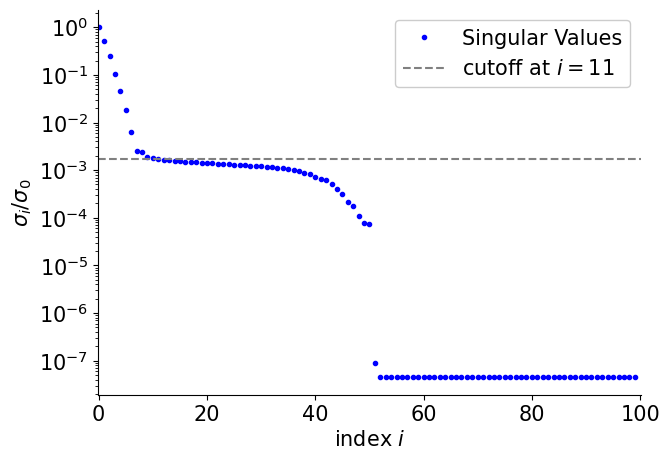

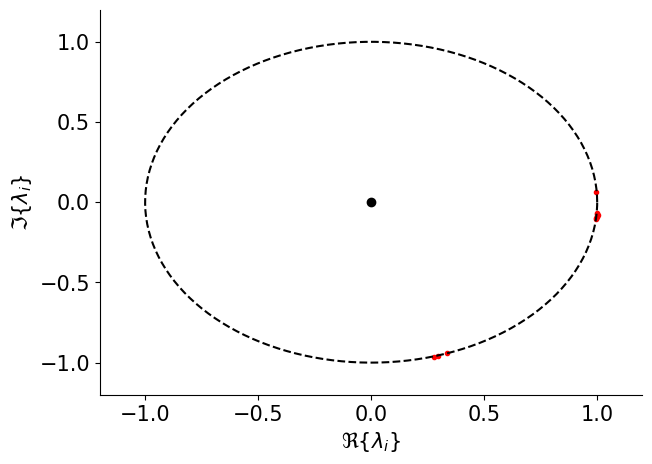

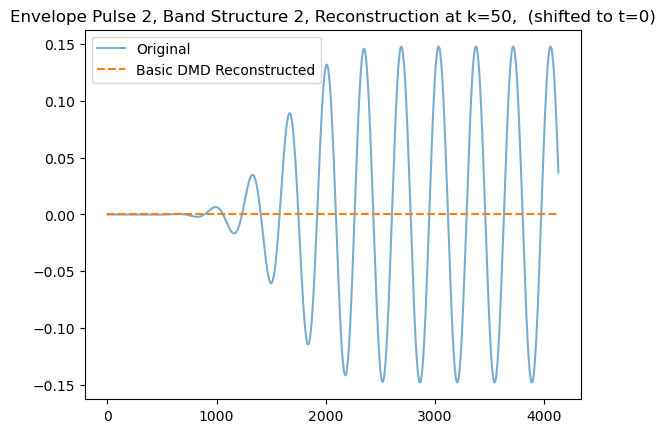

In [ ]:

# ====== Set up the simulation ======
#-------------- Envelope Pulse 1 / Band structure 2--------------

case = 2
FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 0.3
efield_case1 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
t = np.linspace(0, 100, 1000)/ cst.tfs
J      = 1.0/cst.Ry
delta  = 0.5/cst.Ry
k_list = np.linspace(-np.pi, np.pi, 101)[:-1]

t_span= (t[0],t[-1])

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
limits=np.array([[0,100],[0.0,0.2]])



#Get the simualtion ready for DMD use:
t_dmd = t[:-1]  # because X and Y have 999 time steps
X = solutions[:, 0, :-1]  # shape: (num_k, len(t)-1)
Y = solutions[:, 0, 1:]   # one step ahead




# ========= Apply DMD ===========
rank=11
index=50
#truncamiento=-6


eigvals, Phi_L, r_L, S      = Hamiltonian.perform_dmd(X, Y, t, rank)
mu, Phi_M, r_M, Sig2 = Hamiltonian.DMD(X, Y, False, orden_truncado=rank)
plotting.plot_singular_values(Sig2,rank, False) 
plotting.plot_eigenvalues(mu)


delay = 1  # we will use this number of delays throughout the tutorial    (600)      
dmd = DMD(svd_rank=rank)
delay_dmd = hankel_preprocessing(dmd, d=delay)
delay_dmd.fit(X)

# Reconstruction
X_dmd = dmd.reconstructed_data.real  # or .imag or .abs()
# Optional: get eigenvalues or modes
eigs = dmd.eigs
modes = dmd.modes



# Chop the first 399 time points to align with DMD output
t_dmd_shifted = t_dmd[:1000-delay] #1000-delay
#t_dmd_shifted = t_dmd[delay-1:] #use this line instead of the line above and DMD will stop working (also reset delay=2)

# Truncate DMD data to match the shortened time axis
x_dmd_shifted = X_dmd[index].real[:len(t_dmd_shifted)] 


# Plot
plt.plot(t_dmd, X[index].real, label="Original", alpha=0.6)
plt.plot(t_dmd_shifted, x_dmd_shifted, label="Basic DMD Reconstructed", linestyle='--') #delayed_DMD Reconstructed
plt.legend()
plt.title(f"Envelope Pulse 2, Band Structure 2, Reconstruction at k={index},  (shifted to t=0)") #simple pulse 2
plt.show()



In [131]:
"""



# ====== Set up the simulation ======



#-------------- Simple Pulse 1 / Band structure 2--------------
case = 1
FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 1.2
efield_case1 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
t = np.linspace(0, 100, 1000)/ cst.tfs
J      = 1.0/cst.Ry
delta  = 0.5/cst.Ry
k_list = np.linspace(-np.pi, np.pi, 101)[:-1]

t_span= (t[0],t[-1])


solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
limits=np.array([[0,100],[0.0,0.2]])



#Get the simualtion ready for DMD use:
t_dmd = t[:-1]  # because X and Y have 999 time steps
X = solutions[:, 0, :-1]  # shape: (num_k, len(t)-1)
Y = solutions[:, 0, 1:]   # one step ahead




# ========= Apply DMD ===========
rank=11
index=50
#truncamiento=-6


eigvals, Phi_L, r_L, S      = Hamiltonian.perform_dmd(X, Y, t, rank)
mu, Phi_M, r_M, Sig2 = Hamiltonian.DMD(X, Y, False, orden_truncado=rank)
plotting.plot_singular_values(Sig2,rank, False) 
plotting.plot_eigenvalues(mu)


delay = 400  # we will use this number of delays throughout the tutorial         
dmd = DMD(svd_rank=rank)
delay_dmd = hankel_preprocessing(dmd, d=delay)
delay_dmd.fit(X)

# Reconstruction
X_dmd = dmd.reconstructed_data.real  # or .imag or .abs()
# Optional: get eigenvalues or modes
eigs = dmd.eigs
modes = dmd.modes

# Chop the first 399 time points to align with DMD output
t_dmd_shifted = t_dmd[:1000-delay] #1000-delay
#t_dmd_shifted = t_dmd[delay-1:] #use this line instead of the line above and DMD will stop working (also reset delay=2)

# Truncate DMD data to match the shortened time axis
x_dmd_shifted = X_dmd[index].real[:len(t_dmd_shifted)] 


# Plot
plt.plot(t_dmd, X[index].real, label="Original", alpha=0.6)
plt.plot(t_dmd_shifted, x_dmd_shifted, label="Basic DMD Reconstructed", linestyle='--') #Delayed_DMD Reconstructed
plt.legend()
plt.title(f"Simple Pulse 1, Band Structure 2, Reconstruction at k={index},  (shifted to t=0)")                    ##simple pulse 1
plt.show()



"""


'\n\n\n\n# ====== Set up the simulation ======\n\n\n\n#-------------- Simple Pulse 1 / Band structure 2--------------\ncase = 1\nFWHM  = 20. / cst.tfs\nsigma = FWHM/(2.0*np.sqrt(2*np.log(2)))\nE0 = 1.2\nefield_case1 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )\nt = np.linspace(0, 100, 1000)/ cst.tfs\nJ      = 1.0/cst.Ry\ndelta  = 0.5/cst.Ry\nk_list = np.linspace(-np.pi, np.pi, 101)[:-1]\n\nt_span= (t[0],t[-1])\n\n\nsolutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)\nfor k_i,k in enumerate(k_list):\n    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)\n    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)\n    solutions[k_i,0,:] = sol.y[2]\n    solutions[k_i,1,:] = sol.y[3]\nlimits=np.array([[0,100],[0.0,0.2]])\n\n\n\n#Get the simualtion ready for DMD use:\nt_dmd = t[:-1]  # because X and Y have 999 time steps\nX = solutions[:, 0, :-1]  # shape: (num_k, len(t)-1)\nY = solutions[:, 0, 1:]   # o

# Studing the different Ks

### Three cases with the envelope pulse


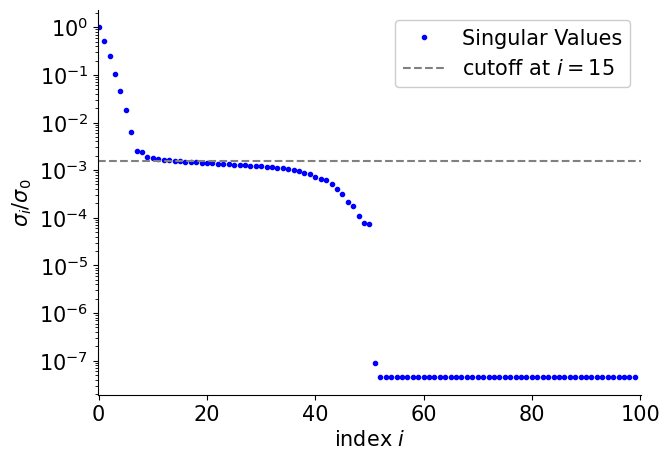

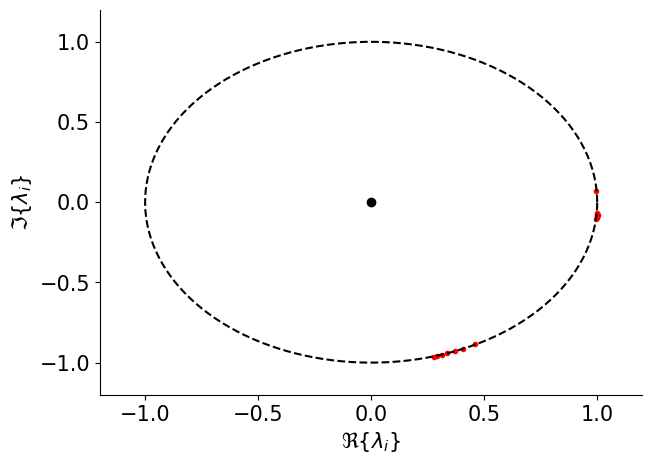

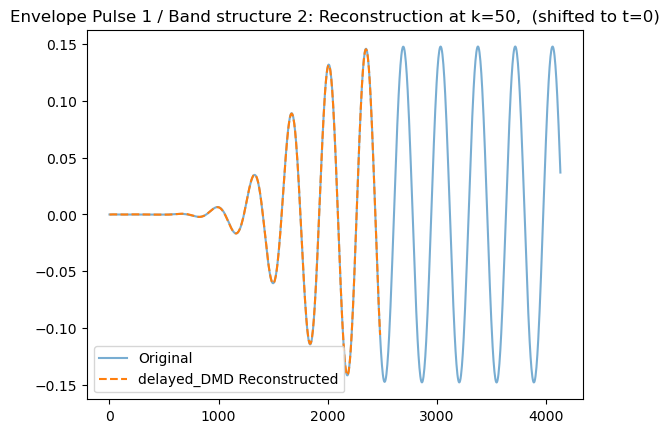

In [132]:

# ====== Set up the simulation ======
#-------------- Envelope Pulse 1 / Band structure 2--------------

case = 2
FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 0.3
efield_case1 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
t = np.linspace(0, 100, 1000)/ cst.tfs
J      = 1.0/cst.Ry
delta  = 0.5/cst.Ry
k_list = np.linspace(-np.pi, np.pi, 101)[:-1]

t_span= (t[0],t[-1])

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
limits=np.array([[0,100],[0.0,0.2]])

#Get the simualtion ready for DMD use:
t_dmd = t[:-1]  # because X and Y have 999 time steps
X = solutions[:, 0, :-1]  # shape: (num_k, len(t)-1)
Y = solutions[:, 0, 1:]   # one step ahead

# ========= Apply DMD ===========
rank=15
index=50
#truncamiento=-6


eigvals, Phi_L, r_L, S      = Hamiltonian.perform_dmd(X, Y, t, rank)
mu, Phi_M, r_M, Sig2 = Hamiltonian.DMD(X, Y, False, orden_truncado=rank)
plotting.plot_singular_values(Sig2,rank, False) 
plotting.plot_eigenvalues(mu)


delay = 400  #
dmd = DMD(svd_rank=rank)
delay_dmd = hankel_preprocessing(dmd, d=delay)
delay_dmd.fit(X)

# Reconstruction
X_dmd = dmd.reconstructed_data.real  # or .imag or .abs()
# Optional: get eigenvalues or modes
eigs = dmd.eigs
modes = dmd.modes

# Chop the first 399 time points to align with DMD output
t_dmd_shifted = t_dmd[:600]
#t_dmd_shifted = t_dmd[delay-1:] #use this line instead of the line above and DMD will stop working (also reset delay=2)

# Truncate DMD data to match the shortened time axis
x_dmd_shifted = X_dmd[index].real[:len(t_dmd_shifted)] 


# Plot
plt.plot(t_dmd, X[index].real, label="Original", alpha=0.6)
plt.plot(t_dmd_shifted, x_dmd_shifted, label="delayed_DMD Reconstructed", linestyle='--')
plt.legend()
plt.title(f"Envelope Pulse 1 / Band structure 2: Reconstruction at k={index},  (shifted to t=0)")
plt.show()



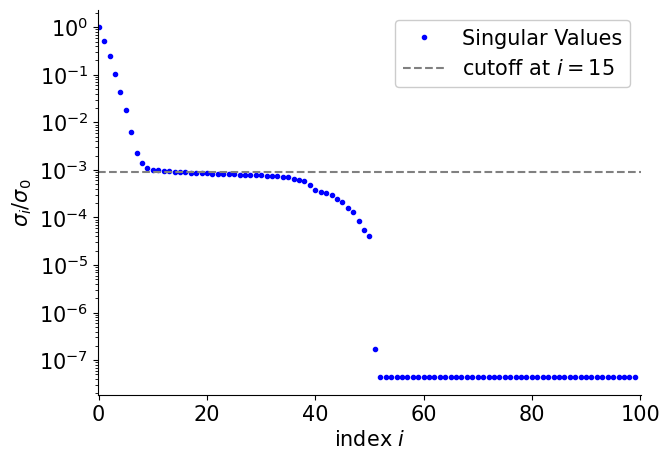

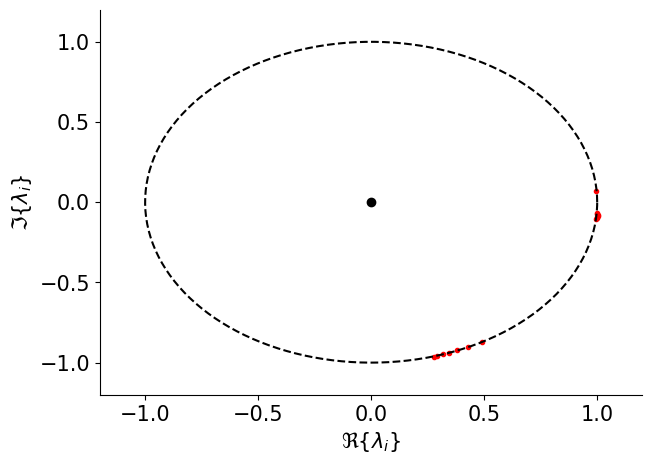

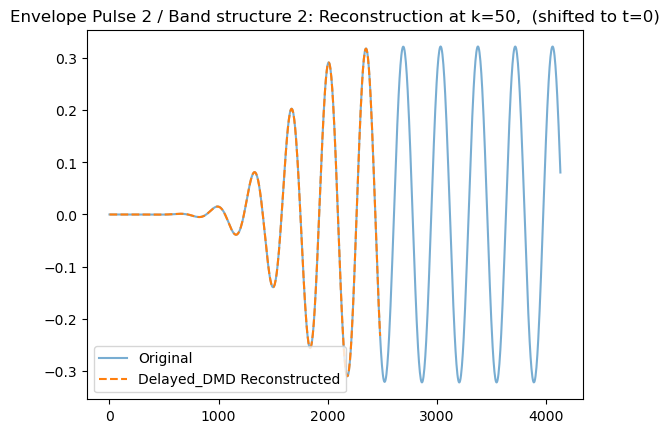

In [133]:

# ====== Set up the simulation ======
#-------------- Envelope Pulse 2 / Band structure 2--------------

case = 2
FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 0.7
efield_case1 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
t = np.linspace(0, 100, 1000)/ cst.tfs
J      = 1.0/cst.Ry
delta  = 0.5/cst.Ry
k_list = np.linspace(-np.pi, np.pi, 101)[:-1]

t_span= (t[0],t[-1])

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
limits=np.array([[0,100],[0.0,0.2]])



#Get the simualtion ready for DMD use:
t_dmd = t[:-1]  # because X and Y have 999 time steps
X = solutions[:, 0, :-1]  # shape: (num_k, len(t)-1)
Y = solutions[:, 0, 1:]   # one step ahead


# ========= Apply DMD ===========
rank=15
index=50
#truncamiento=-6


eigvals, Phi_L, r_L, S      = Hamiltonian.perform_dmd(X, Y, t, rank)
mu, Phi_M, r_M, Sig2 = Hamiltonian.DMD(X, Y, False, orden_truncado=rank)
plotting.plot_singular_values(Sig2,rank, False) 
plotting.plot_eigenvalues(mu)


delay = 400  # we will use this number of delays throughout the tutorial         
dmd = DMD(svd_rank=rank)
delay_dmd = hankel_preprocessing(dmd, d=delay)
delay_dmd.fit(X)

# Reconstruction
X_dmd = dmd.reconstructed_data.real  # or .imag or .abs()
# Optional: get eigenvalues or modes
eigs = dmd.eigs
modes = dmd.modes

# Chop the first 399 time points to align with DMD output
t_dmd_shifted = t_dmd[:600]
#t_dmd_shifted = t_dmd[delay-1:] #use this line instead of the line above and DMD will stop working (also reset delay=2)

# Truncate DMD data to match the shortened time axis
x_dmd_shifted = X_dmd[index].real[:len(t_dmd_shifted)] 


# Plot
plt.plot(t_dmd, X[index].real, label="Original", alpha=0.6)
plt.plot(t_dmd_shifted, x_dmd_shifted, label="Delayed_DMD Reconstructed", linestyle='--')
plt.legend()
plt.title(f"Envelope Pulse 2 / Band structure 2: Reconstruction at k={index},  (shifted to t=0)")
plt.show()



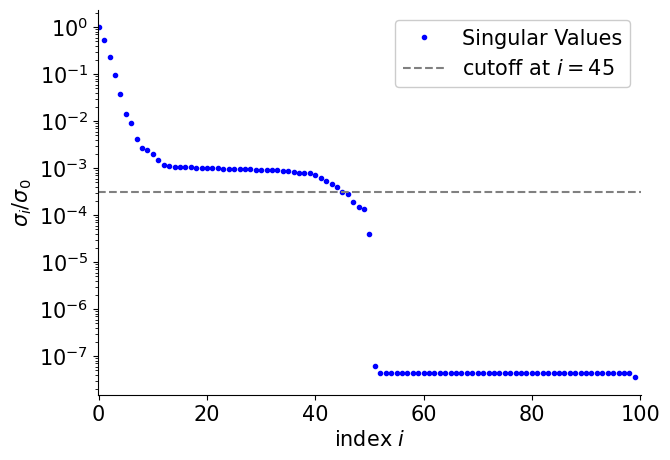

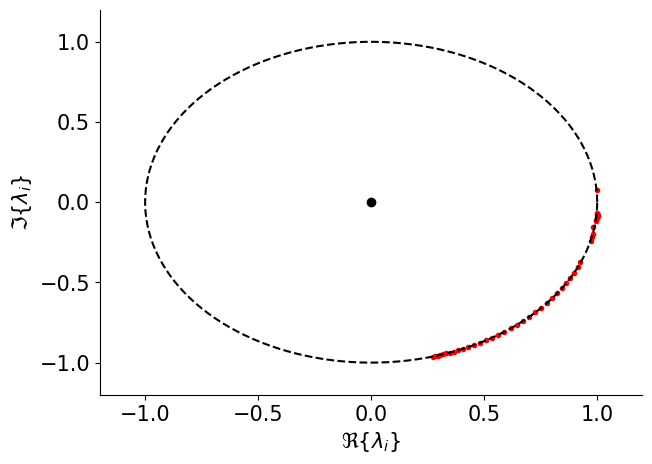

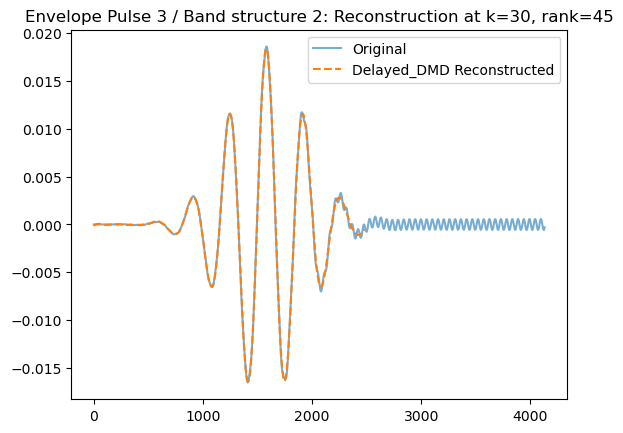

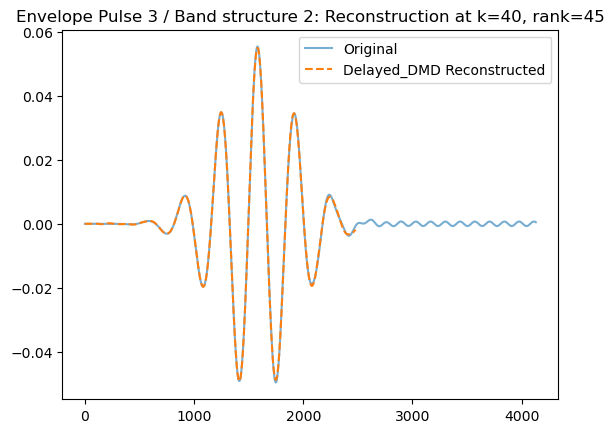

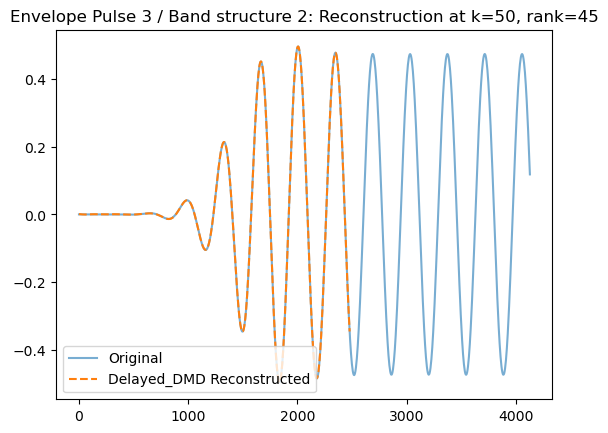

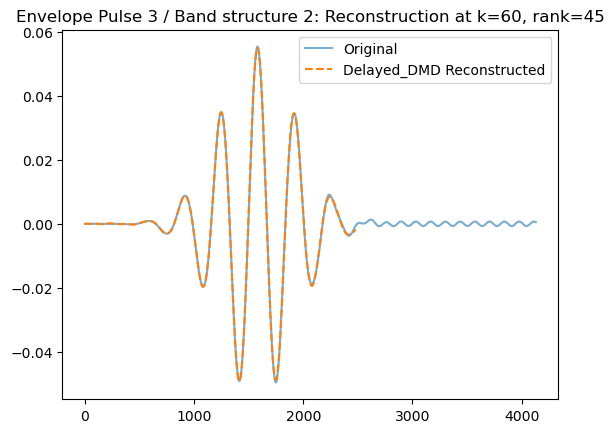

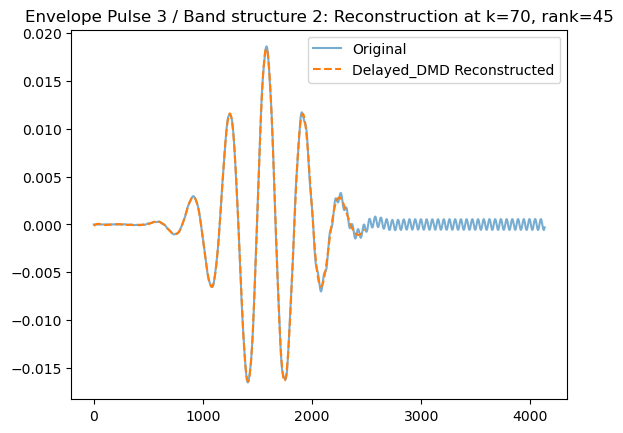

In [134]:

# ====== Set up the simulation ======
#-------------- Envelope Pulse 3 (E0=1.9) / Band structure 2--------------

case = 2
FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 1.9
efield_case1 = Hamiltonian.E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
t = np.linspace(0, 100, 1000)/ cst.tfs
J      = 1.0/cst.Ry
delta  = 0.5/cst.Ry
k_list = np.linspace(-np.pi, np.pi, 101)[:-1]

t_span= (t[0],t[-1])

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: Hamiltonian.rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    #Now we are interested in the coherence rho_vc and rho_cv
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
limits=np.array([[0,100],[0.0,0.2]])



#Get the simualtion ready for DMD use:
t_dmd = t[:-1]  # because X and Y have 999 time steps
X = solutions[:, 0, :-1]  # shape: (num_k, len(t)-1)
Y = solutions[:, 0, 1:]   # one step ahead


# ========= Apply DMD ===========
rank=45
#truncamiento=-6


eigvals, Phi_L, r_L, S      = Hamiltonian.perform_dmd(X, Y, t, rank)
mu, Phi_M, r_M, Sig2 = Hamiltonian.DMD(X, Y, False, orden_truncado=rank)
plotting.plot_singular_values(Sig2,rank, False) 
plotting.plot_eigenvalues(mu)


delay = 400  # 
dmd = DMD(svd_rank=rank)
delay_dmd = hankel_preprocessing(dmd, d=delay)
delay_dmd.fit(X)

# Reconstruction
X_dmd = dmd.reconstructed_data.real  # or .imag or .abs()
# Optional: get eigenvalues or modes
eigs = dmd.eigs
modes = dmd.modes

# Chop the first 399 time points to align with DMD output
t_dmd_shifted = t_dmd[:1000-delay]
#t_dmd_shifted = t_dmd[delay-1:] #use this line instead of the line above and DMD will stop working (also reset delay=2)



for index in range (30, 80, 10):
    # Truncate DMD data to match the shortened time axis
    x_dmd_shifted = X_dmd[index].real[:len(t_dmd_shifted)] 
    # Plot
    plt.plot(t_dmd, X[index].real, label="Original", alpha=0.6)
    plt.plot(t_dmd_shifted, x_dmd_shifted, label="Delayed_DMD Reconstructed", linestyle='--')
    plt.legend()
    plt.title(f"Envelope Pulse 3 / Band structure 2: Reconstruction at k={index}, rank={rank}")
    plt.show()












# Without using the time delay (Without the pulse starting at $t_0=0$)

This is out of curiosity, to compare with the problems I had in my own implementation of DMD reconstruction. 

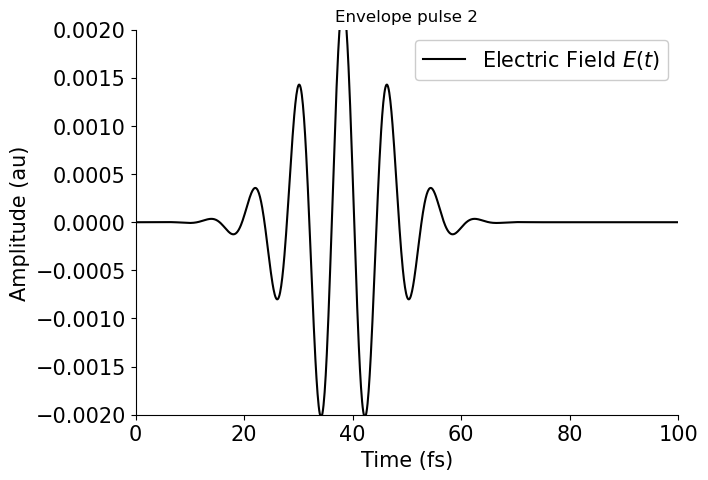

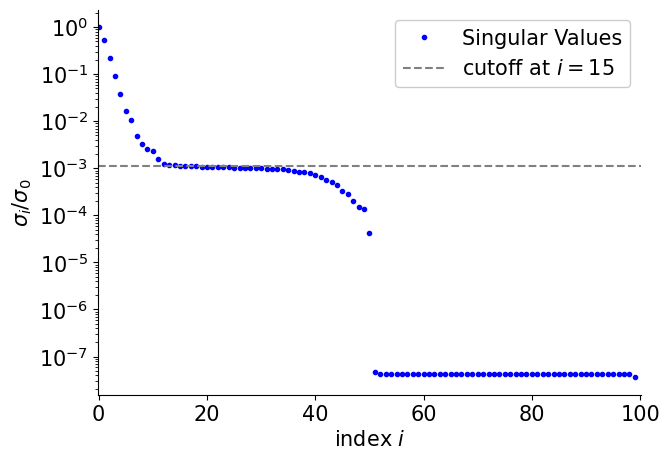

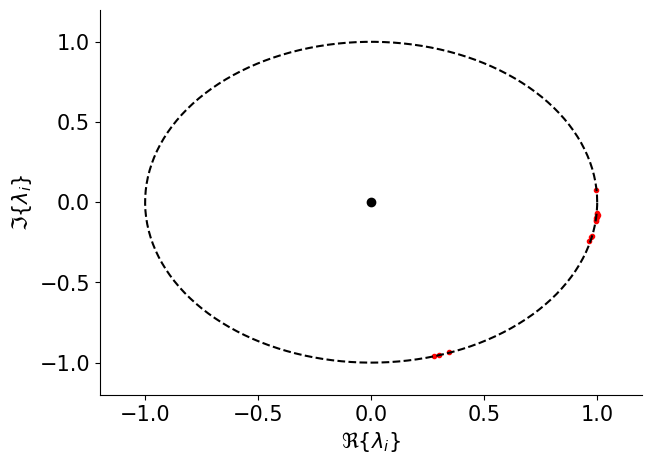

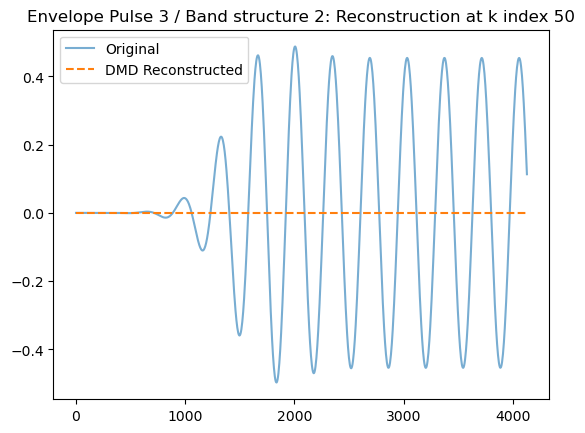

In [135]:
#========================================================================================
#============================      System      ==========================================
def eps_vb(k, J, delta):
    return  2. * J * np.cos(k) - 2. * J - delta / 2.

def eps_cb(k, J, delta):
    return -2. * J * np.cos(k) + 2. * J + delta / 2.

def delta_epsilon(k, J, delta):
    return eps_cb(k,J, delta) - eps_vb(k,J, delta)



def E(t, sigma, E0, ω=0,case=1, t0=None):
    if t0 == None:
        t0=4.5*sigma

    if case==1:
        return E0 / (np.sqrt(2 * np.pi * sigma ** 2)) * np.exp((-(t - t0) ** 2) / (2 * sigma ** 2))
    if case==2:
        return E0 / (np.sqrt(2 * np.pi * sigma ** 2)) * np.exp((-(t - t0) ** 2) / (2 * sigma ** 2)) * np.cos(ω * (t - t0))

def V(t, k, sigma, E0, ω=0,case=1):
    return -E(t, sigma, E0, ω, case) #* D(k)

#========================================================================================
#============================  Density Operator =========================================

def A(t, k, J, delta, sigma, E0, ω, case):
    v = V(t, k, sigma, E0, ω, case)
    dE = delta_epsilon(k, J, delta)
    return np.array([
        [0,     0,     -1j * v,   1j * v],
        [0,     0,      1j * v,  -1j * v],
        [-1j * v, 1j * v, -1j * dE,     0],
        [1j * v, -1j * v,     0,  -1j * dE]
    ], dtype=np.complex64)

def rhs(t, y, k, J, delta, sigma, E0, ω=0,case=1):
    return A(t, k, J, delta, sigma, E0, ω,case) @ y




# ====== Set up the simulation ======
#-------------- Envelope Pulse 3 / Band structure 2--------------

case = 2
FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 2.0
t = np.linspace(0, 100, 1000)/ cst.tfs

efield_case1 = E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
plotting.plot_electric_pulse("Envelope pulse 2", t*cst.tfs, efield_case1, np.array([[0,100],[-0.002,0.002]]),fout='')

J      = 1.0/cst.Ry
delta  = 0.5/cst.Ry
k_list = np.linspace(-np.pi, np.pi, 101)[:-1]

t_span= (t[0],t[-1])

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
limits=np.array([[0,100],[0.0,0.2]])



#Get the simualtion ready for DMD use:
t_dmd = t[:-1]  # because X and Y have 999 time steps
X = solutions[:, 0, :-1]  # shape: (num_k, len(t)-1)
Y = solutions[:, 0, 1:]   # one step ahead


# ========= Apply DMD ===========
rank=15 # 35
#truncamiento=-6


eigvals, Phi_L, r_L, S      = Hamiltonian.perform_dmd(X, Y, t, rank)
mu, Phi_M, r_M, Sig2 = Hamiltonian.DMD(X, Y, False, orden_truncado=rank)
plotting.plot_singular_values(Sig2,rank, False) 
plotting.plot_eigenvalues(mu)


delay = 2  # we will use this number of delays throughout the tutorial         
dmd = DMD(svd_rank=rank)
#delay_dmd = hankel_preprocessing(dmd, d=delay)
#delay_dmd.fit(X)
dmd.fit(X)

# Reconstruction
X_dmd = dmd.reconstructed_data.real  # or .imag or .abs()
# Optional: get eigenvalues or modes
eigs = dmd.eigs
modes = dmd.modes

# Chop the first 399 time points to align with DMD output
#t_dmd_shifted = t_dmd[:998]
#t_dmd_shifted = t_dmd[delay-1:] #use this line instead of the line above and DMD will stop working (also reset delay=2)

# Truncate DMD data to match the shortened time axis
#x_dmd_shifted = X_dmd[50].real[:len(t_dmd_shifted)] 


# Plot
plt.plot(t_dmd, X[50].real, label="Original", alpha=0.6)
plt.plot(t_dmd, X_dmd[50].real, label="DMD Reconstructed", linestyle='--')
plt.legend()
plt.title("Envelope Pulse 3 / Band structure 2: Reconstruction at k index 50")
plt.show()



# Without using the time delay (With the pulse starting at $t_0=0$)

This is out of curiosity, to compare with the problems I had in my own implementation of DMD reconstruction. 

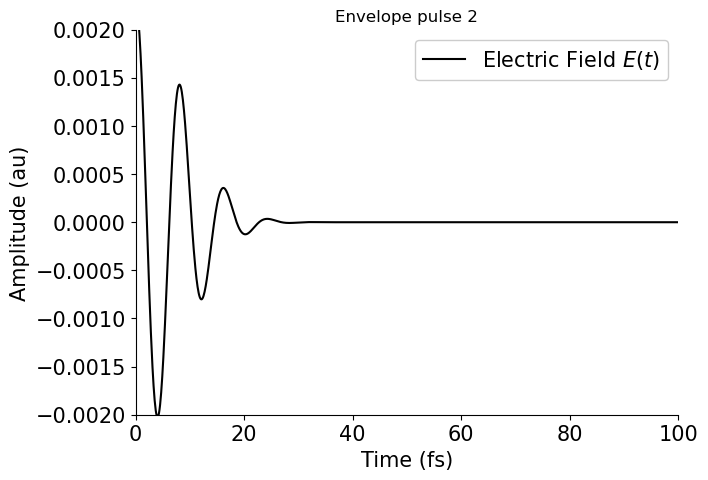

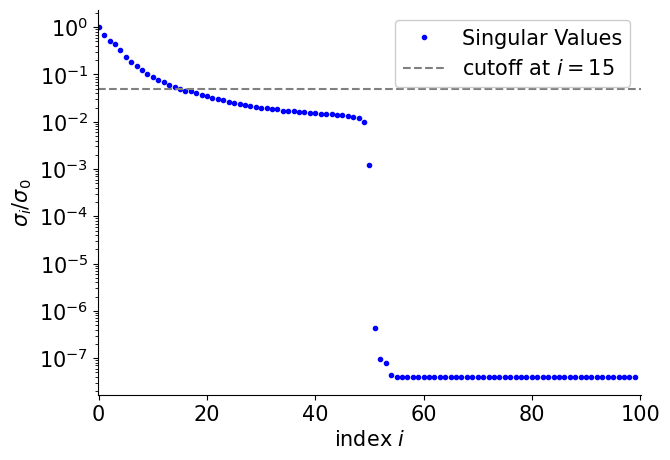

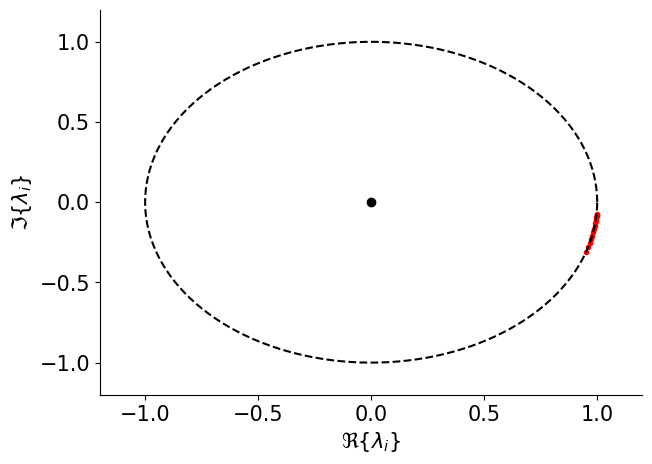

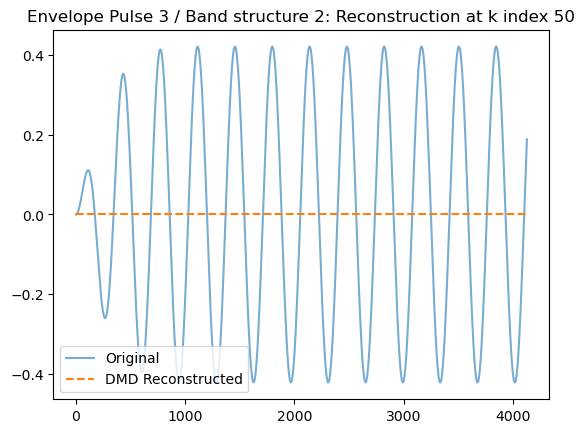

In [136]:
#========================================================================================
#============================      System      ==========================================
def eps_vb(k, J, delta):
    return  2. * J * np.cos(k) - 2. * J - delta / 2.

def eps_cb(k, J, delta):
    return -2. * J * np.cos(k) + 2. * J + delta / 2.

def delta_epsilon(k, J, delta):
    return eps_cb(k,J, delta) - eps_vb(k,J, delta)



def E(t, sigma, E0, ω=0,case=1, t0=None):
    if t0 == None:
        t0=0#t0=4.5*sigma

    if case==1:
        return E0 / (np.sqrt(2 * np.pi * sigma ** 2)) * np.exp((-(t - t0) ** 2) / (2 * sigma ** 2))
    if case==2:
        return E0 / (np.sqrt(2 * np.pi * sigma ** 2)) * np.exp((-(t - t0) ** 2) / (2 * sigma ** 2)) * np.cos(ω * (t - t0))

def V(t, k, sigma, E0, ω=0,case=1):
    return -E(t, sigma, E0, ω, case) #* D(k)

#========================================================================================
#============================  Density Operator =========================================

def A(t, k, J, delta, sigma, E0, ω, case):
    v = V(t, k, sigma, E0, ω, case)
    dE = delta_epsilon(k, J, delta)
    return np.array([
        [0,     0,     -1j * v,   1j * v],
        [0,     0,      1j * v,  -1j * v],
        [-1j * v, 1j * v, -1j * dE,     0],
        [1j * v, -1j * v,     0,  -1j * dE]
    ], dtype=np.complex64)

def rhs(t, y, k, J, delta, sigma, E0, ω=0,case=1):
    return A(t, k, J, delta, sigma, E0, ω,case) @ y




# ====== Set up the simulation ======
#-------------- Envelope Pulse 3 / Band structure 2--------------

case = 2
FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 2.0
t = np.linspace(0, 100, 1000)/ cst.tfs

efield_case1 = E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
plotting.plot_electric_pulse("Envelope pulse 2", t*cst.tfs, efield_case1, np.array([[0,100],[-0.002,0.002]]),fout='')

J      = 1.0/cst.Ry
delta  = 0.5/cst.Ry
k_list = np.linspace(-np.pi, np.pi, 101)[:-1]

t_span= (t[0],t[-1])

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
limits=np.array([[0,100],[0.0,0.2]])



#Get the simualtion ready for DMD use:
t_dmd = t[:-1]  # because X and Y have 999 time steps
X = solutions[:, 0, :-1]  # shape: (num_k, len(t)-1)
Y = solutions[:, 0, 1:]   # one step ahead


# ========= Apply DMD ===========
rank=15 # 35
#truncamiento=-6


eigvals, Phi_L, r_L, S      = Hamiltonian.perform_dmd(X, Y, t, rank)
mu, Phi_M, r_M, Sig2 = Hamiltonian.DMD(X, Y, False, orden_truncado=rank)
plotting.plot_singular_values(Sig2,rank, False) 
plotting.plot_eigenvalues(mu)


delay = 2  # we will use this number of delays throughout the tutorial         
dmd = DMD(svd_rank=rank)
#delay_dmd = hankel_preprocessing(dmd, d=delay)
#delay_dmd.fit(X)
dmd.fit(X)

# Reconstruction
X_dmd = dmd.reconstructed_data.real  # or .imag or .abs()
# Optional: get eigenvalues or modes
eigs = dmd.eigs
modes = dmd.modes

# Chop the first 399 time points to align with DMD output
#t_dmd_shifted = t_dmd[:998]
#t_dmd_shifted = t_dmd[delay-1:] #use this line instead of the line above and DMD will stop working (also reset delay=2)

# Truncate DMD data to match the shortened time axis
#x_dmd_shifted = X_dmd[50].real[:len(t_dmd_shifted)] 


# Plot
plt.plot(t_dmd, X[50].real, label="Original", alpha=0.6)
plt.plot(t_dmd, X_dmd[50].real, label="DMD Reconstructed", linestyle='--')
plt.legend()
plt.title("Envelope Pulse 3 / Band structure 2: Reconstruction at k index 50")
plt.show()



# Doing the same but with the simple pulse (Still at $t_0=0$)

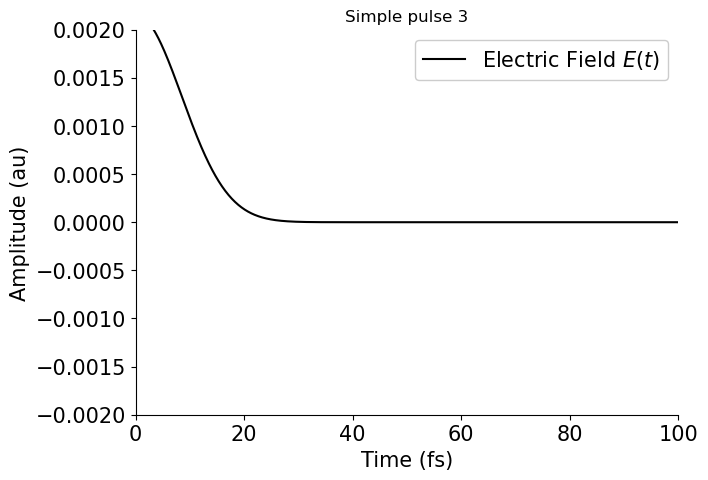

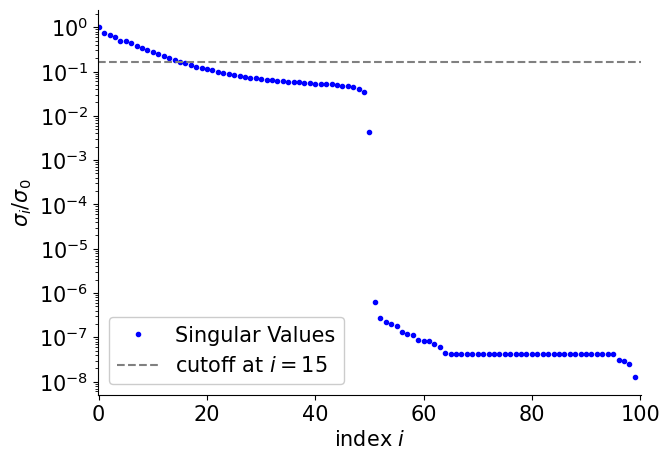

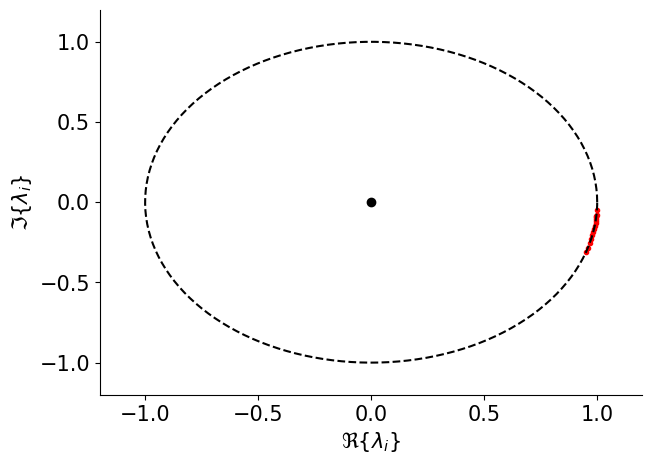

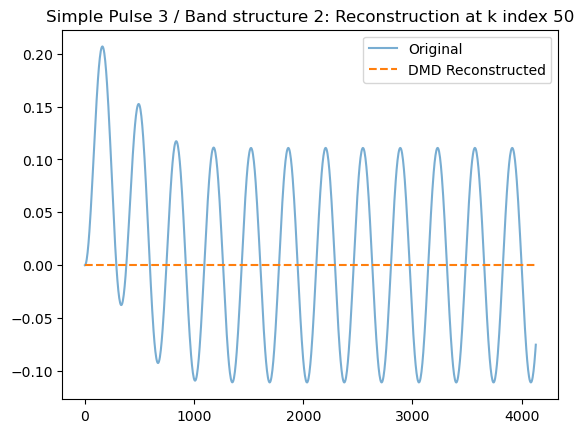

In [137]:



# ====== Set up the simulation ======
#-------------- Simple Pulse 3 / Band structure 2--------------

case = 1
FWHM  = 20. / cst.tfs
sigma = FWHM/(2.0*np.sqrt(2*np.log(2)))
E0 = 1.9
t = np.linspace(0, 100, 1000)/ cst.tfs

efield_case1 = E(t, sigma,E0, ω=0.5/cst.Ry, case=case )
plotting.plot_electric_pulse("Simple pulse 3", t*cst.tfs, efield_case1, np.array([[0,100],[-0.002,0.002]]),fout='')

J      = 1.0/cst.Ry
delta  = 0.5/cst.Ry
k_list = np.linspace(-np.pi, np.pi, 101)[:-1]

t_span= (t[0],t[-1])

solutions=np.zeros((len(k_list),2,len(t)),dtype=np.complex64)
for k_i,k in enumerate(k_list):
    y0 = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    sol = solve_ivp(lambda t, y: rhs(t, y, k, J, delta, sigma, E0, ω=0.5/cst.Ry,case=case), t_span, y0, t_eval=t)
    solutions[k_i,0,:] = sol.y[2]
    solutions[k_i,1,:] = sol.y[3]
limits=np.array([[0,100],[0.0,0.2]])



#Get the simualtion ready for DMD use:
t_dmd = t[:-1]  # because X and Y have 999 time steps
X = solutions[:, 0, :-1]  # shape: (num_k, len(t)-1)
Y = solutions[:, 0, 1:]   # one step ahead


# ========= Apply DMD ===========
rank= 15
#truncamiento=-6


eigvals, Phi_L, r_L, S      = Hamiltonian.perform_dmd(X, Y, t, rank)
mu, Phi_M, r_M, Sig2 = Hamiltonian.DMD(X, Y, False, orden_truncado=rank)
plotting.plot_singular_values(Sig2,rank, False) 
plotting.plot_eigenvalues(mu)


delay = 2  # we will use this number of delays throughout the tutorial         
dmd = DMD(svd_rank=rank)
#delay_dmd = hankel_preprocessing(dmd, d=delay)
#delay_dmd.fit(X)
dmd.fit(X)

# Reconstruction
X_dmd = dmd.reconstructed_data.real  # or .imag or .abs()
# Optional: get eigenvalues or modes
eigs = dmd.eigs
modes = dmd.modes


# Plot
plt.plot(t_dmd, X[50].real, label="Original", alpha=0.6)
plt.plot(t_dmd, X_dmd[50].real, label="DMD Reconstructed", linestyle='--')
plt.legend()
plt.title("Simple Pulse 3 / Band structure 2: Reconstruction at k index 50")
plt.show()



# The Magnon simulation: Full time evolution (10'000 steps)

In [138]:
import numpy as np
import h5py

In [139]:
with h5py.File('Data_48_Test.h5', 'r') as f:
    print("Keys in the HDF5 file:", list(f.keys()))
    # Read the snapshots dataset
    fmag_ext = f['fmag_ext'][:]
    kvecs = f['kvecs'][:]
        
    # Get the attributes nk_lin, nt and dt
    nk_lin = f.attrs['nk_lin']
    nt = f.attrs['nt']
    dt = f.attrs['dt']
    

Keys in the HDF5 file: ['fmag_ext', 'kvecs']


In [140]:
print(f'nk_lin: {nk_lin}')
print(f'nt: {nt}')
print(f'dt: {dt}')
print()
print(f'len(kvecs): {len(kvecs)}')
print(f'fmag_ext.shape:{fmag_ext.shape}')
print()
print(f'fmag_ext: {fmag_ext}')

nk_lin: 48
nt: 100000
dt: 0.005

len(kvecs): 2304
fmag_ext.shape:(10001, 48, 48)

fmag_ext: [[[0.00055144 0.00078375 0.00109509 ... 0.00109509 0.00078375 0.00055144]
  [0.00078375 0.00111182 0.00155043 ... 0.00155043 0.00111182 0.00078375]
  [0.00109509 0.00155043 0.00215762 ... 0.00215762 0.00155043 0.00109509]
  ...
  [0.00109509 0.00155043 0.00215762 ... 0.00215762 0.00155043 0.00109509]
  [0.00078375 0.00111182 0.00155043 ... 0.00155043 0.00111182 0.00078375]
  [0.00055144 0.00078375 0.00109509 ... 0.00109509 0.00078375 0.00055144]]

 [[0.00055144 0.00078375 0.00109509 ... 0.00109509 0.00078375 0.00055144]
  [0.00078375 0.00111182 0.00155043 ... 0.00155043 0.00111182 0.00078375]
  [0.00109509 0.00155043 0.00215762 ... 0.00215762 0.00155043 0.00109509]
  ...
  [0.00109509 0.00155043 0.00215762 ... 0.00215762 0.00155043 0.00109509]
  [0.00078375 0.00111182 0.00155043 ... 0.00155043 0.00111182 0.00078375]
  [0.00055144 0.00078375 0.00109509 ... 0.00109509 0.00078375 0.00055144]]

 [[0

In [141]:
#Recasting the data from a [10000, 48, 48] => [100, 48**2]
fmag_ext_new = fmag_ext.reshape(np.shape(fmag_ext)[0],np.shape(fmag_ext)[1]**2)
fmag_ext_order = np.einsum('tk->kt',fmag_ext_new)
X_gen=fmag_ext_order[: ,  :]
X = fmag_ext_order[: ,  :-1]
Y = fmag_ext_order[: , 1:  ]

In [142]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from pydmd import DMD
from pydmd.plotter import plot_eigs, plot_summary
from pydmd.preprocessing import hankel_preprocessing

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.linalg as LA

import Hamiltonian as HamiltonianA
import Plotting as plotting
import constants as cst

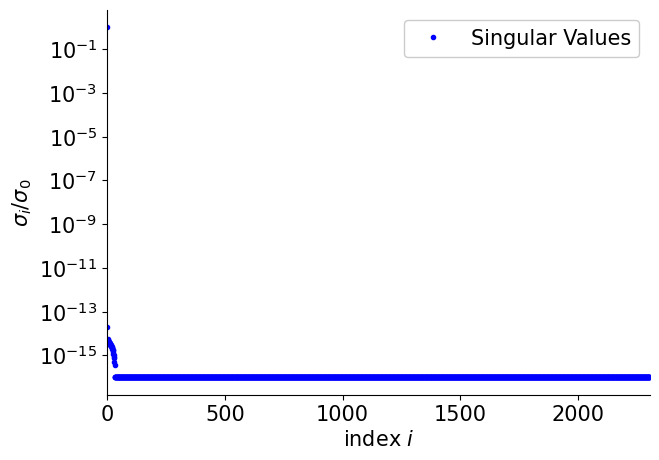

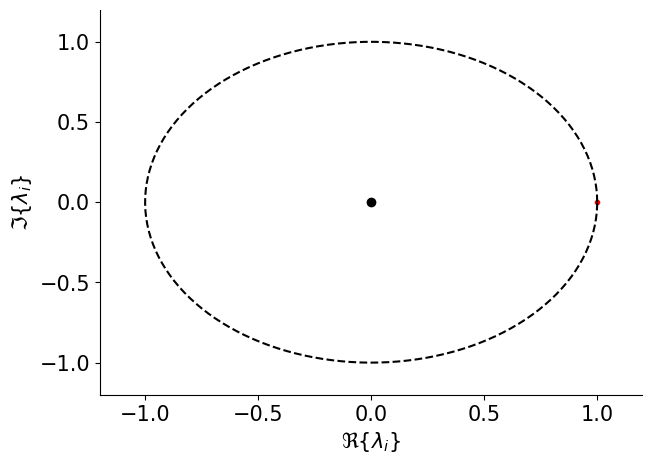

0

In [144]:
rank=1
dmd = DMD(svd_rank=rank)
dmd.fit(X)
X_dmd = dmd.reconstructed_data.real  # or .imag or .abs()
eigs = dmd.eigs
modes = dmd.modes



#copy-paste: to check
t = np.linspace(0, 10000, 1000)
t_dmd = t[:-1]  # because X and Y have 999 time steps

rank=-6

#eigvals, Phi_L, r_L, S      = Hamiltonian.perform_dmd(X, Y, t, rank)
mu, Phi_M, r_M, Sig2 = Hamiltonian.DMD(X, Y, False, orden_truncado=rank)
plotting.plot_singular_values(Sig2,rank, False) 
plotting.plot_eigenvalues(mu)


#time to run: 1m1.3s (with: t = np.linspace(0, 100, 1000))

# Full Magnon simulation

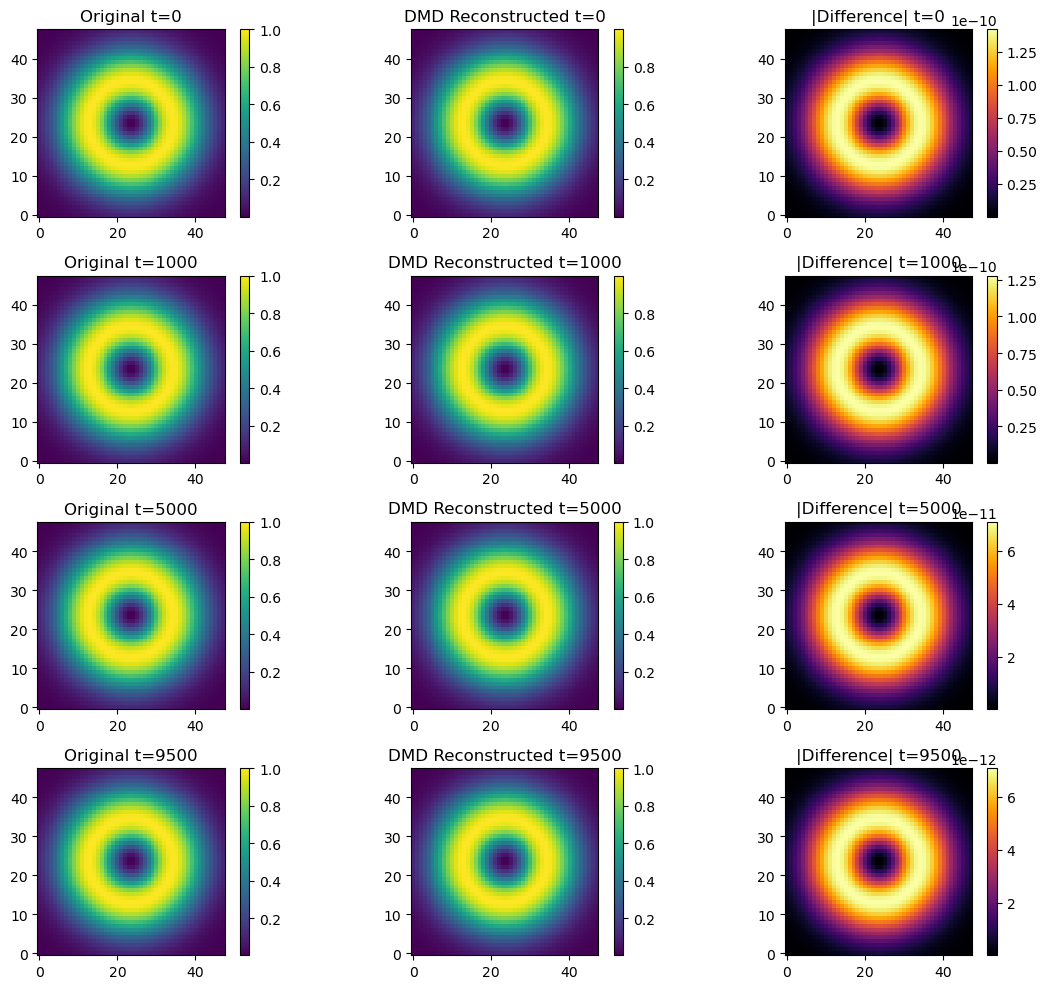

In [145]:

# Reconstruct the signal using PyDMD
X_dmd_reconstructed = dmd.reconstructed_data.real  # Can also use .imag or .abs() depending on your needs

# Choose a few time indices to visualize
time_indices = [0, 1000, 5000, 9500]

# Normalize both datasets for fair comparison
X_gen_normalized = X_gen / np.max(X_gen)
X_dmd_normalized = X_dmd / np.max(X_dmd)

# Reshape and plot as 48x48 images
fig, axes = plt.subplots(len(time_indices), 3, figsize=(12, 2.5 * len(time_indices)))
for i, idx in enumerate(time_indices):
    ax1, ax2, ax3 = axes[i]

    im1 = ax1.imshow(X_gen_normalized[:, idx].reshape(48, 48), cmap='viridis', origin='lower')
    ax1.set_title(f'Original t={idx}')
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    im2 = ax2.imshow(X_dmd_normalized[:, idx].reshape(48, 48), cmap='viridis', origin='lower')
    ax2.set_title(f'DMD Reconstructed t={idx}')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    diff = np.abs(X_gen_normalized[:, idx] - X_dmd_normalized[:, idx]).reshape(48, 48)
    im3 = ax3.imshow(diff, cmap='inferno', origin='lower')
    ax3.set_title(f'|Difference| t={idx}')
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

5.037636974236648e-15


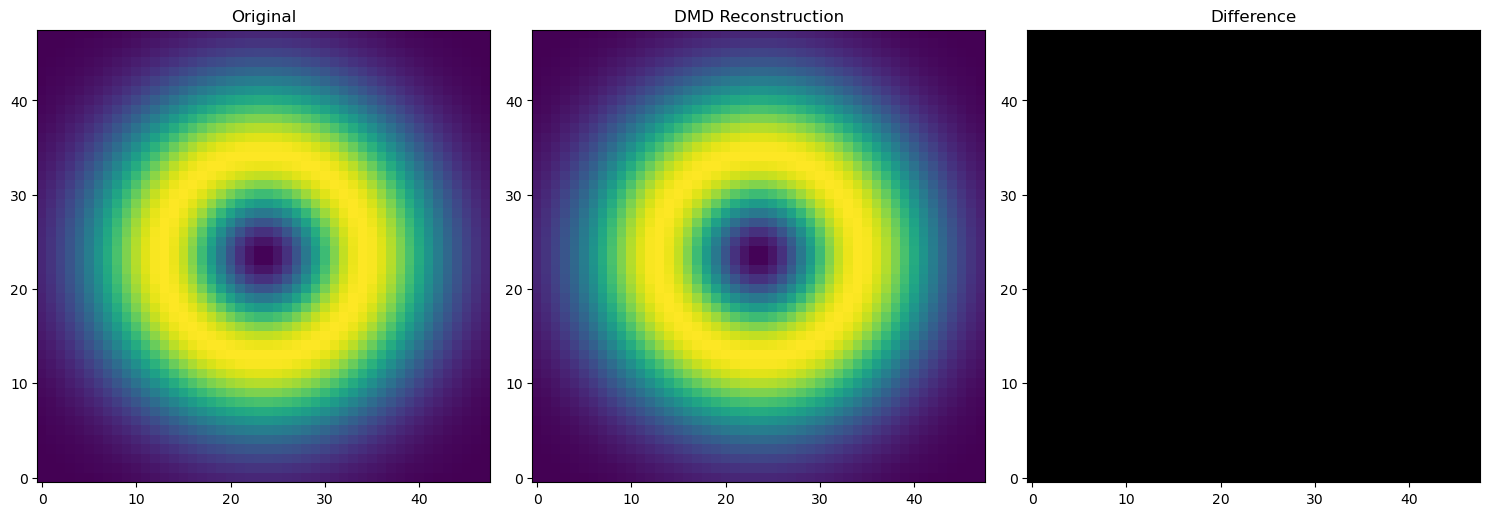

In [146]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Normalize original and DMD reconstructions for fair comparison
X_gen_norm = X_gen / np.max(X_gen)
X_dmd_norm = X_dmd / np.max(X_dmd)

# No normalization for raw difference
diff_all = np.abs(X - X_dmd)


# Set up the figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

im1 = ax1.imshow(X_gen_norm[:, 0].reshape(48, 48), cmap='viridis', origin='lower', animated=True)
ax1.set_title('Original')

im2 = ax2.imshow(X_dmd_norm[:, 0].reshape(48, 48), cmap='viridis', origin='lower', animated=True)
ax2.set_title('DMD Reconstruction')

im3 = ax3.imshow(diff_all[:, 0].reshape(48, 48), cmap='gray', origin='lower', animated=True, vmin=0, vmax=0.0001)
print(np.max(diff_all[:, 0].reshape(48, 48)))
ax3.set_title('Difference')

plt.tight_layout()

def update(frame):
    orig = X_gen_norm[:, frame].reshape(48, 48)
    recon = X_dmd_norm[:, frame].reshape(48, 48)
    diff = np.abs(X[:, frame] - X_dmd[:, frame]).reshape(48, 48)

    im1.set_array(orig)
    im2.set_array(recon)
    im3.set_array(diff)
    return [im1, im2, im3]

ani = animation.FuncAnimation(fig, update, frames=99, interval=100, blit=True)

# Save combined video
ani.save("full_comparison.mp4", fps=10, dpi=150)

plt.show()